# Credit Risk Assessment & Default Prediction Framework (LendingClub)

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_sample = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=5)

In [3]:
cols_preview = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=0)
print(f"Total columns in file: {len(cols_preview.columns)}")
print(cols_preview.columns.tolist())

Total columns in file: 151
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_statu

In [4]:
df = pd.read_csv('accepted_2007_to_2018Q4.csv')

print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Shape: (2260701, 151)
Memory usage: 6.66 GB


In [5]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [6]:
leakage_cols = [
    'out_prncp', 'out_prncp_inv',        # outstanding principal - only known post-disbursement
    'total_pymnt', 'total_pymnt_inv',     # total payment made - only known after repayment
    'total_rec_prncp', 'total_rec_int',   # recovered amounts - post-default
    'total_rec_late_fee', 'recoveries',   # recovery data - post-default
    'collection_recovery_fee',            # post-collection
    'last_pymnt_d', 'last_pymnt_amnt',    # last payment info - during loan lifecycle
    'next_pymnt_d',                       # future payment date
    'debt_settlement_flag', 'debt_settlement_flag_date',  # settlement = post-default
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term'
]

In [7]:
admin_cols = [
    'id', 'member_id',      # unique identifiers, no signal
    'url',                   # loan URL
    'desc',                  # free text description (advanced NLP project later)
    'title',                 # loan title - noisy free text
    'emp_title',             # employer name - 300K+ unique values, unstructured
    'zip_code',              # too granular, use addr_state instead
    'policy_code',           # always = 1 in this dataset, zero variance
    'pymnt_plan',            # almost always 'n', zero variance
]

In [8]:
hardship_cols = [
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount'
]

joint_cols = [
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog'
]

In [9]:
# Step 1: Create target variable
# Keep only clean terminal states - best practice from top Kaggle notebooks
keep_status = ['Fully Paid', 'Charged Off']
df = df[df['loan_status'].isin(keep_status)]
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

print(df['target'].value_counts())
print(f"Default rate: {df['target'].mean():.2%}")
# Expected: ~80% Fully Paid, ~20% Charged Off

target
0    1076751
1     268559
Name: count, dtype: int64
Default rate: 19.96%


In [10]:
# Step 2: Drop leakage + admin + hardship + joint cols
drop_cols = leakage_cols + admin_cols + hardship_cols + joint_cols + ['loan_status']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f"Remaining columns: {df.shape[1]}")
# Expected: ~65-70 cols remaining, then we'll further refine

Remaining columns: 92


In [11]:
# Step 3: Check missing value % - community standard practice
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0.3])  # Drop cols with >30% missing - industry threshold

mths_since_last_record            0.830110
mths_since_recent_bc_dlq          0.762865
mths_since_last_major_derog       0.737049
mths_since_recent_revol_delinq    0.665533
il_util                           0.654343
mths_since_rcnt_il                0.610958
all_util                          0.600430
inq_last_12m                      0.600392
total_cu_tl                       0.600392
open_acc_6m                       0.600392
inq_fi                            0.600391
open_rv_12m                       0.600391
open_il_12m                       0.600391
open_rv_24m                       0.600391
open_il_24m                       0.600391
open_act_il                       0.600391
max_bal_bc                        0.600391
total_bal_il                      0.600391
mths_since_last_delinq            0.504525
dtype: float64


In [12]:
# Good:Bad Odds = 1076751 / 268559 ≈ 4.01 : 1

In [13]:
# Drop all columns with >30% missing EXCEPT mths_since_last_delinq
high_missing = missing[missing > 0.30].index.tolist()
high_missing = [c for c in high_missing if c != 'mths_since_last_delinq']
df = df.drop(columns=high_missing)

# Special treatment: convert mths_since_last_delinq to binary flag
# Missing = never delinquent (good borrower signal)
df['ever_delinquent'] = df['mths_since_last_delinq'].notnull().astype(int)
df = df.drop(columns=['mths_since_last_delinq'])

print(f"Columns after sparse drop: {df.shape[1]}")
print(f"\nEver delinquent rate: {df['ever_delinquent'].mean():.2%}")

Columns after sparse drop: 74

Ever delinquent rate: 49.55%


In [14]:
# These pairs are near-identical (>95% correlation) - community notebooks confirm this
# Keeping both adds noise not signal - called multicollinearity in credit risk
near_duplicate_cols = [
    'funded_amnt',        # ~identical to loan_amnt
    'funded_amnt_inv',    # ~identical to loan_amnt
    'fico_range_high',    # keep fico_range_low as primary (conservative estimate)
    'last_fico_range_high', 'last_fico_range_low',  # post-origination data
    'last_credit_pull_d', # post-origination administrative field
    'disbursement_method' # operational field, no credit signal
]
df = df.drop(columns=[c for c in near_duplicate_cols if c in df.columns])

print(f"Columns after duplicate drop: {df.shape[1]}")
print(f"\nRemaining columns:\n{df.columns.tolist()}")

Columns after duplicate drop: 67

Remaining columns:
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m

In [15]:
# These overlap with the target event window - soft leakage
soft_leakage = [
    'chargeoff_within_12_mths',  # charge-off during loan = overlaps with target
    'num_tl_30dpd',              # 30 DPD during loan = target leakage
    'num_tl_90g_dpd_24m',        # 90+ DPD 24 months = overlaps with Charged Off label
    'num_tl_120dpd_2m',          # 120 DPD last 2 months = near-perfect leakage
    'delinq_amnt',               # delinquency amount during loan period
    'acc_now_delinq',            # currently delinquent = happens during loan
]
df = df.drop(columns=[c for c in soft_leakage if c in df.columns])

# Drop near-zero variance cols (>99% same value) - called constants in banking
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        if df[col].nunique() <= 1:
            df = df.drop(columns=[col])
            print(f"Dropped constant: {col}")

# Check for near-zero variance - flag columns where top value > 99% of rows
for col in df.select_dtypes(include='object').columns:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.99:
        print(f"Near-zero variance (categorical): {col} → top value = {top_freq:.2%}")

print(f"\nFinal working column count: {df.shape[1]}")


Final working column count: 61


In [16]:
import pandas as pd

# 1. Convert term: ' 36 months' → 36 (numeric)
df['term'] = df['term'].str.extract('(\d+)').astype(int)

# 2. Convert int_rate: '10.5%' → 10.5 (if not already float)
if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

# 3. Convert revol_util: '54.3%' → 54.3
if df['revol_util'].dtype == object:
    df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)

# 4. Convert emp_length to ordinal numeric - standard community practice
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_map)
# NaN here means not employed - fill with 0 (conservative credit assumption)
df['emp_length'] = df['emp_length'].fillna(0)

# 5. Extract credit history length in months from earliest_cr_line
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_months'] = (
    (df['issue_d'].dt.year - df['earliest_cr_line'].dt.year) * 12 +
    (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month)
)
# Drop raw date columns - not usable directly in models
df = df.drop(columns=['earliest_cr_line'])

# 6. Extract issue year and month for vintage analysis later
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month
df = df.drop(columns=['issue_d'])

print(df.dtypes.value_counts())
print(f"\nShape: {df.shape}")

float64    48
object      8
int64       3
int32       3
Name: count, dtype: int64

Shape: (1345310, 62)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 62 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1345310 non-null  float64
 1   term                        1345310 non-null  int64  
 2   int_rate                    1345310 non-null  float64
 3   installment                 1345310 non-null  float64
 4   grade                       1345310 non-null  object 
 5   sub_grade                   1345310 non-null  object 
 6   emp_length                  1345310 non-null  float64
 7   home_ownership              1345310 non-null  object 
 8   annual_inc                  1345310 non-null  float64
 9   verification_status         1345310 non-null  object 
 10  purpose                     1345310 non-null  object 
 11  addr_state                  1345310 non-null  object 
 12  dti                         1344936 non-null  float64
 13  de

In [18]:
# Separate categorical and numeric columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['float64','int64','int32']).columns.tolist()
num_cols = [c for c in num_cols if c != 'target']

# Industry standard: impute numeric with MEDIAN (robust to outliers/skew)
# DO NOT use mean - credit features are heavily right-skewed (income, balances)
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical: impute with mode (most frequent)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify - should show 0 missing
print(f"Total missing values remaining: {df.isnull().sum().sum()}")
print(f"Shape confirmed: {df.shape}")

Total missing values remaining: 0
Shape confirmed: (1345310, 62)


In [19]:
# EDA

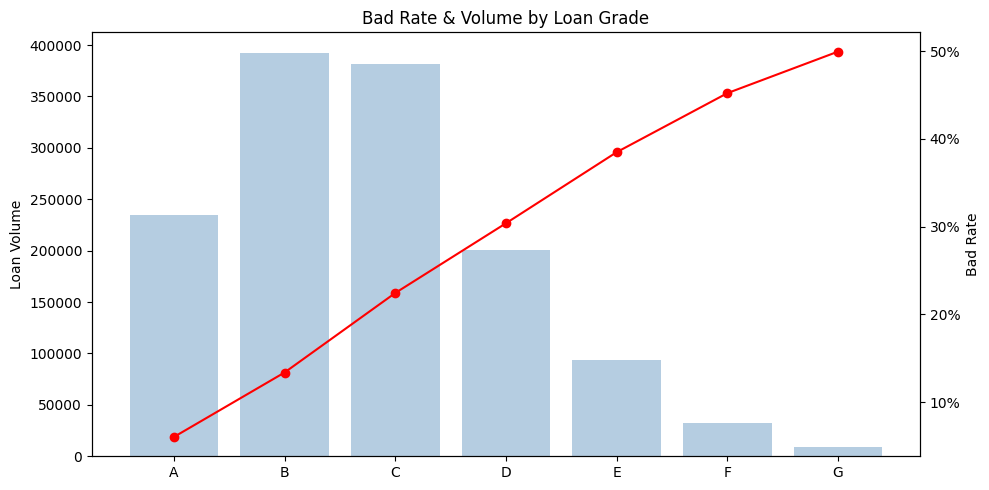

grade  bad_rate  volume
    A  0.060407  235090
    B  0.133852  392741
    C  0.224396  381686
    D  0.303822  200953
    E  0.384784   93650
    F  0.452024   32058
    G  0.499343    9132


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Bad Rate by Grade (most important categorical feature) ---
grade_bad_rate = df.groupby('grade')['target'].agg(['mean','count']).reset_index()
grade_bad_rate.columns = ['grade', 'bad_rate', 'volume']
grade_bad_rate = grade_bad_rate.sort_values('grade')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(grade_bad_rate['grade'], grade_bad_rate['volume'], color='steelblue', alpha=0.4, label='Volume')
ax2.plot(grade_bad_rate['grade'], grade_bad_rate['bad_rate'], color='red', marker='o', label='Bad Rate')
ax1.set_ylabel('Loan Volume')
ax2.set_ylabel('Bad Rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.title('Bad Rate & Volume by Loan Grade')
plt.tight_layout()
plt.savefig('bad_rate_by_grade.png', dpi=150)
plt.show()
print(grade_bad_rate.to_string(index=False))

In [21]:
# --- 2. Bad Rate by Term ---
print("\nBad Rate by Term:")
print(df.groupby('term')['target'].agg(['mean','count'])
      .rename(columns={'mean':'bad_rate','count':'volume'}))

# --- 3. Bad Rate by Home Ownership ---
print("\nBad Rate by Home Ownership:")
print(df.groupby('home_ownership')['target'].agg(['mean','count'])
      .rename(columns={'mean':'bad_rate','count':'volume'})
      .sort_values('bad_rate', ascending=False))

# --- 4. Bad Rate by Verification Status ---
print("\nBad Rate by Verification Status:")
print(df.groupby('verification_status')['target'].agg(['mean','count'])
      .rename(columns={'mean':'bad_rate','count':'volume'}))


Bad Rate by Term:
      bad_rate   volume
term                   
36.0  0.159934  1020743
60.0  0.324454   324567

Bad Rate by Home Ownership:
                bad_rate  volume
home_ownership                  
RENT            0.232165  534421
OWN             0.206198  144832
ANY             0.195804     286
OTHER           0.187500     144
MORTGAGE        0.172077  665579
NONE            0.145833      48

Bad Rate by Verification Status:
                     bad_rate  volume
verification_status                  
Not Verified         0.146746  405701
Source Verified      0.209549  521273
Verified             0.238545  418336


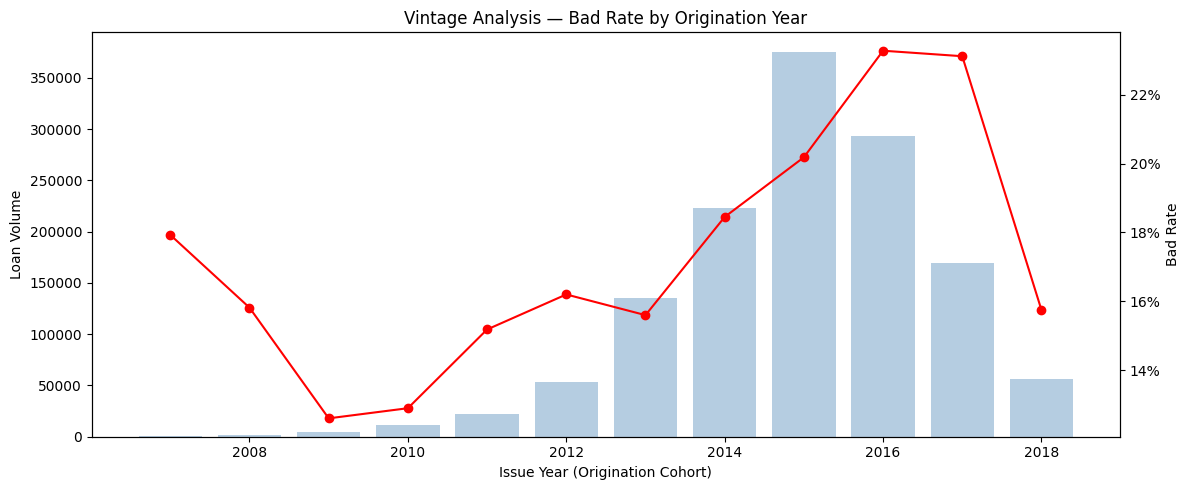

 issue_year  bad_rate  volume
     2007.0  0.179283     251
     2008.0  0.158131    1562
     2009.0  0.125954    4716
     2010.0  0.128901   11536
     2011.0  0.151789   21721
     2012.0  0.161973   53367
     2013.0  0.155960  134804
     2014.0  0.184494  223102
     2015.0  0.201848  375545
     2016.0  0.232832  293095
     2017.0  0.231234  169300
     2018.0  0.157465   56311


In [22]:
# --- 5. VINTAGE ANALYSIS - Bad Rate by Issue Year ---
# This is a mandatory EDA step in any credit risk project [web:92]
vintage = df.groupby('issue_year')['target'].agg(['mean','count']).reset_index()
vintage.columns = ['issue_year', 'bad_rate', 'volume']

fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
ax1.bar(vintage['issue_year'], vintage['volume'], color='steelblue', alpha=0.4, label='Volume')
ax2.plot(vintage['issue_year'], vintage['bad_rate'], color='red', marker='o', label='Bad Rate')
ax1.set_xlabel('Issue Year (Origination Cohort)')
ax1.set_ylabel('Loan Volume')
ax2.set_ylabel('Bad Rate')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.title('Vintage Analysis — Bad Rate by Origination Year')
plt.tight_layout()
plt.savefig('vintage_analysis.png', dpi=150)
plt.show()
print(vintage.to_string(index=False))

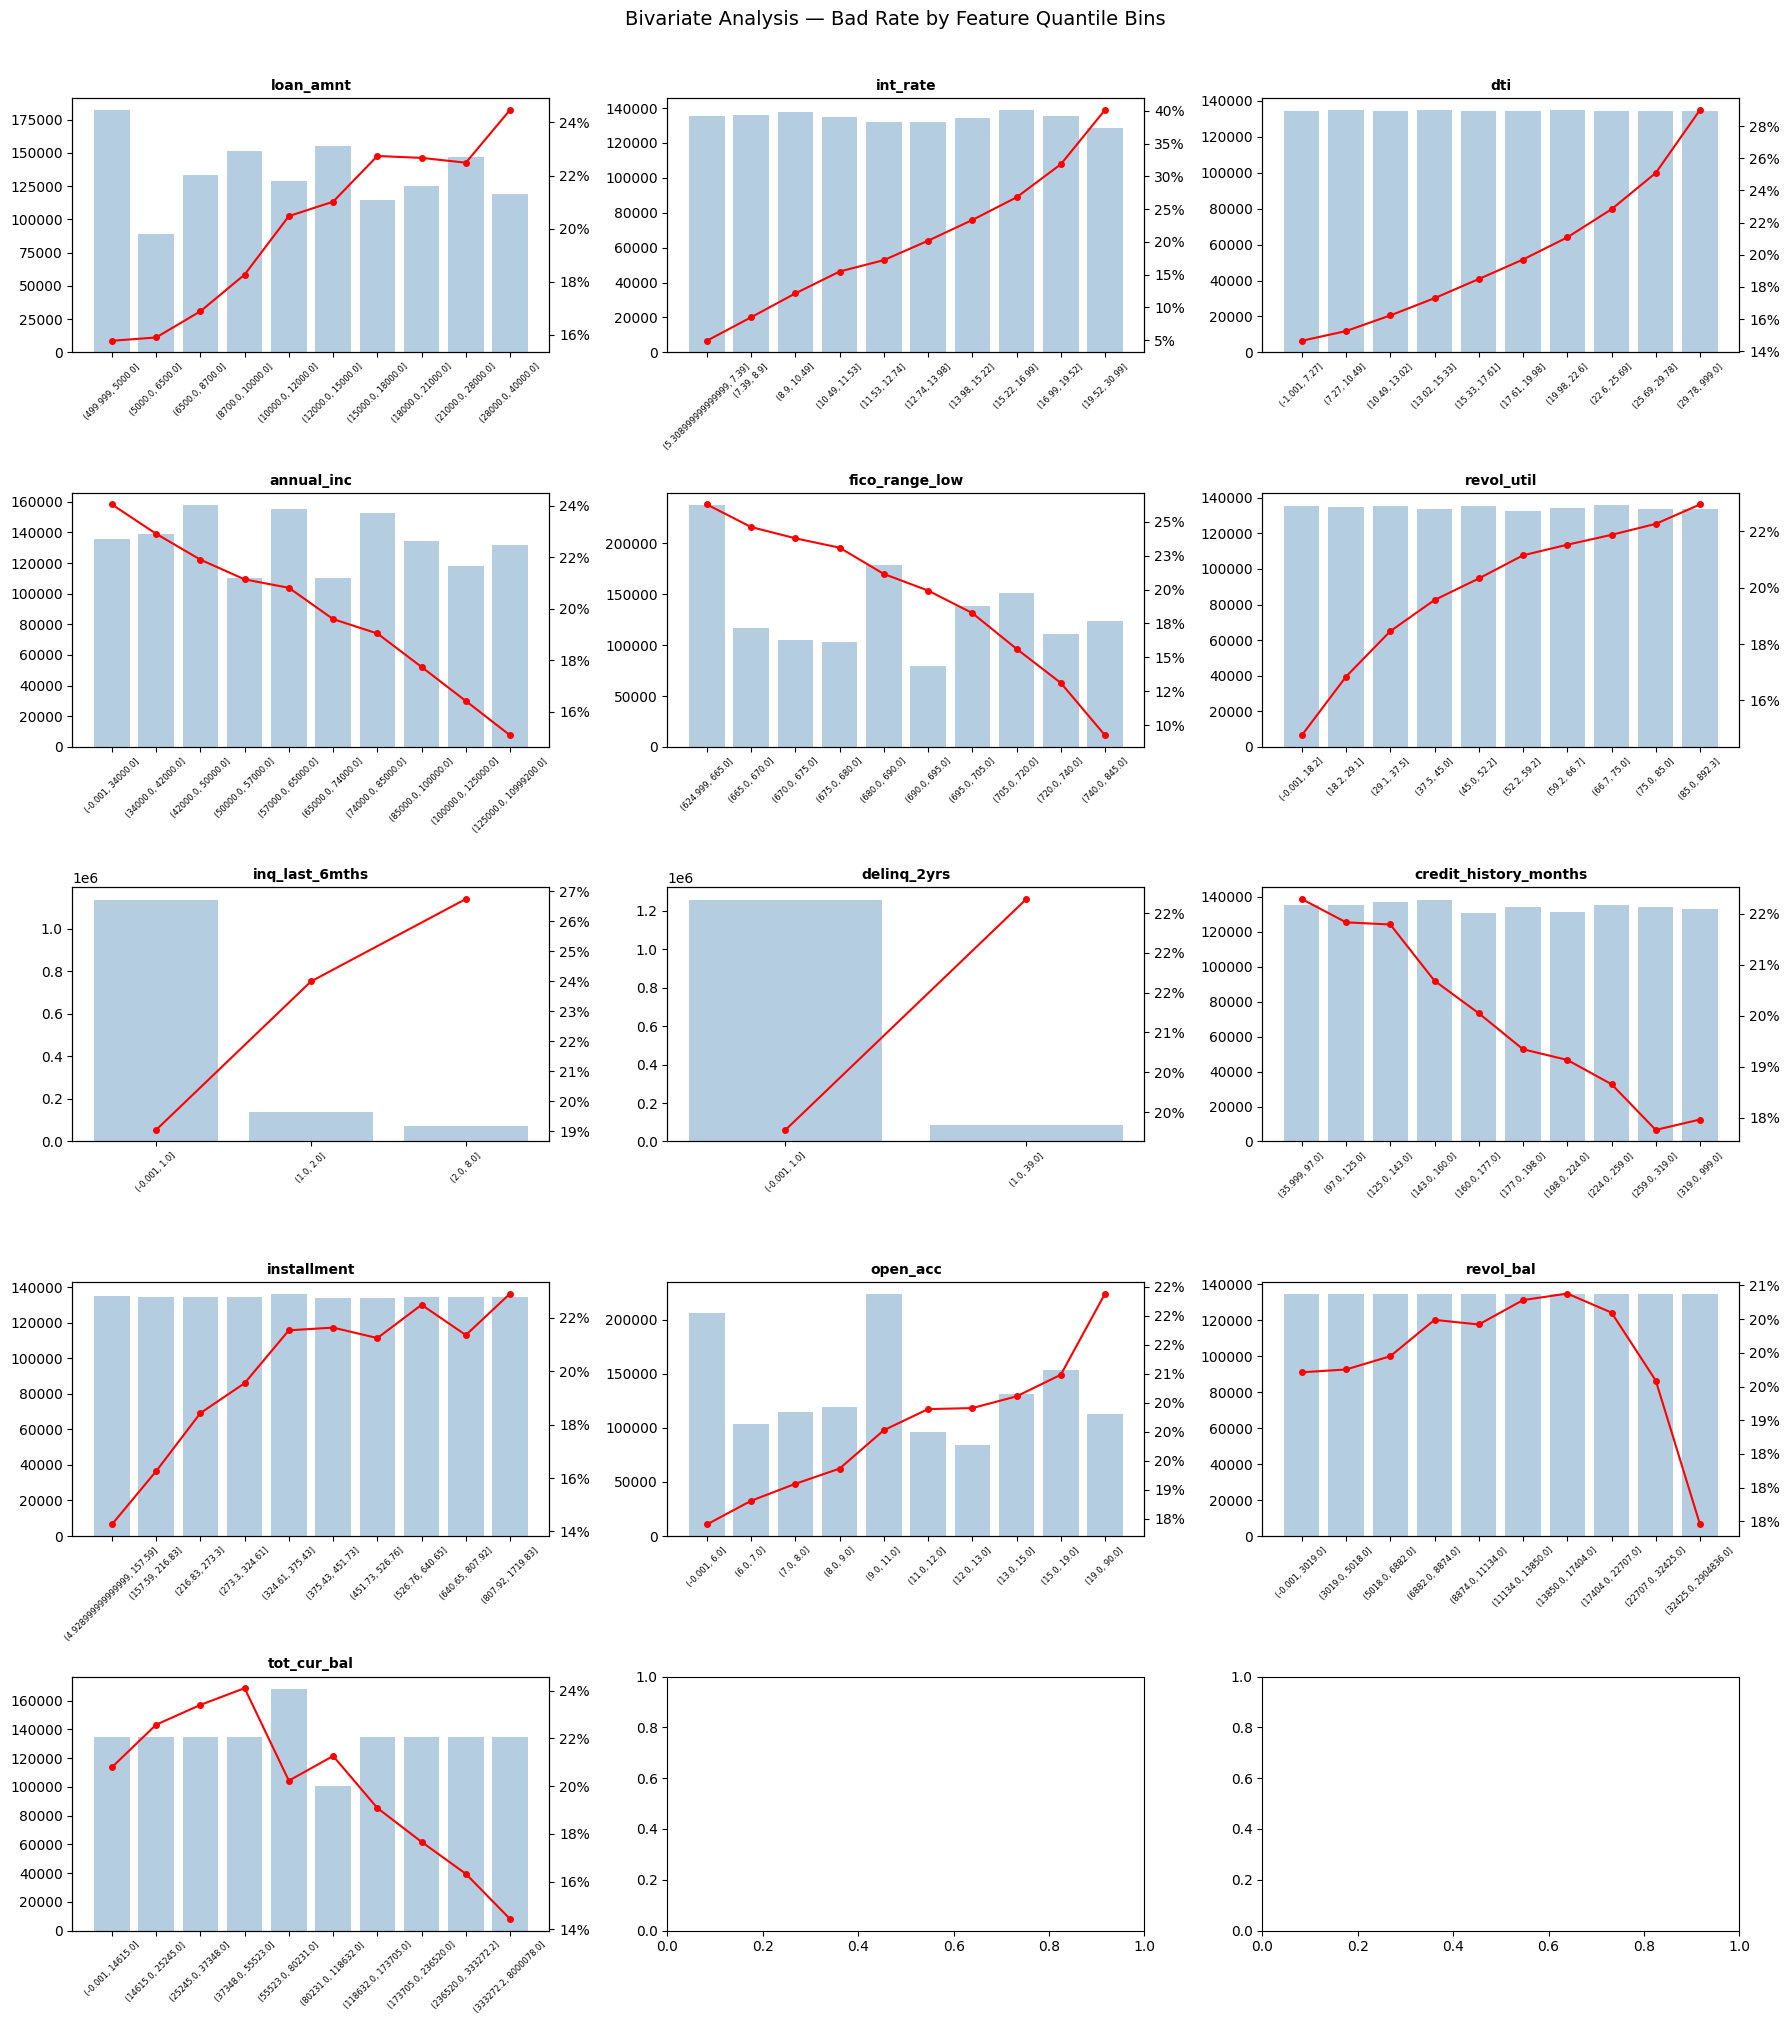

In [23]:
import numpy as np

def bad_rate_by_quantile(df, col, target='target', bins=10):
    """Bin numeric feature into quantiles and compute bad rate per bin"""
    try:
        df['_bin'] = pd.qcut(df[col], q=bins, duplicates='drop')
        result = df.groupby('_bin', observed=True)[target].agg(['mean','count'])
        result.columns = ['bad_rate', 'volume']
        result.index = result.index.astype(str)
        df.drop(columns=['_bin'], inplace=True)
        return result
    except Exception as e:
        return None

# Core numeric features to analyze - the Five C's columns
core_numerics = [
    'loan_amnt', 'int_rate', 'dti', 'annual_inc',
    'fico_range_low', 'revol_util', 'inq_last_6mths',
    'delinq_2yrs', 'credit_history_months', 'installment',
    'open_acc', 'revol_bal', 'tot_cur_bal'
]

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(core_numerics):
    result = bad_rate_by_quantile(df, col)
    if result is not None:
        ax1 = axes[i]
        ax2 = ax1.twinx()
        ax1.bar(range(len(result)), result['volume'], color='steelblue', alpha=0.4)
        ax2.plot(range(len(result)), result['bad_rate'], color='red', marker='o', ms=4)
        ax1.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax1.set_xticks(range(len(result)))
        ax1.set_xticklabels(result.index, rotation=45, fontsize=6)
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Bivariate Analysis — Bad Rate by Feature Quantile Bins', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

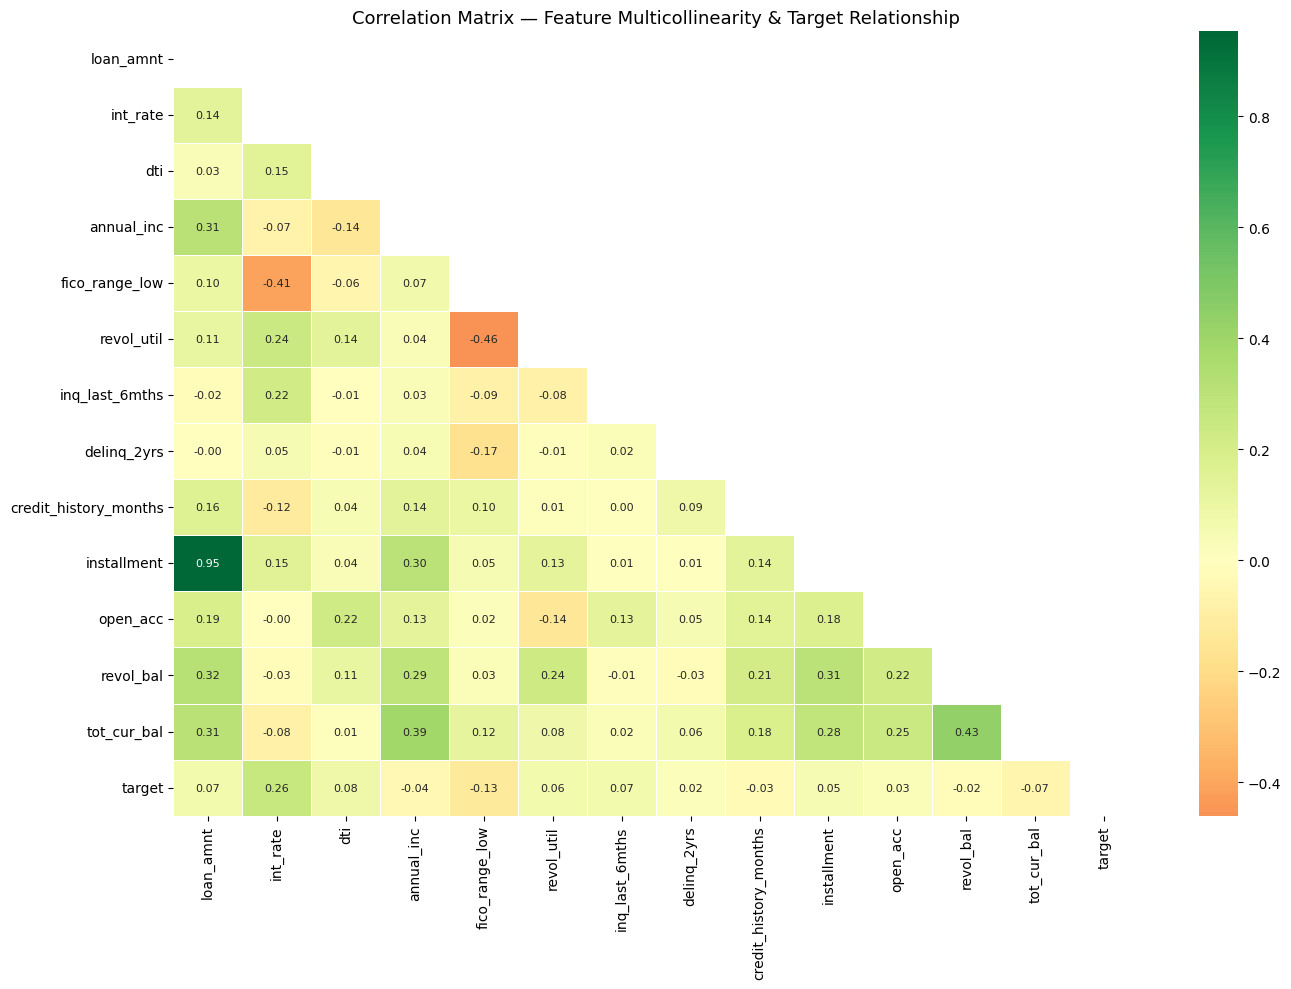


=== Correlation with Default (target) ===
target                   1.000000
int_rate                 0.258792
dti                      0.084499
loan_amnt                0.065604
inq_last_6mths           0.065454
revol_util               0.060029
installment              0.051701
open_acc                 0.028078
delinq_2yrs              0.019381
revol_bal               -0.020010
credit_history_months   -0.033418
annual_inc              -0.041759
tot_cur_bal             -0.067133
fico_range_low          -0.130683


In [24]:
# Select numeric features only for correlation
numeric_features = df[core_numerics + ['target']].copy()

corr_matrix = numeric_features.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix — Feature Multicollinearity & Target Relationship', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Print top correlations with target
print("\n=== Correlation with Default (target) ===")
print(corr_matrix['target'].sort_values(ascending=False).to_string())

In [25]:
# ============================================================
# STAGE 1A: Drop multicollinear feature identified in EDA
# ============================================================
df = df.drop(columns=['installment'])  # 0.95 corr with loan_amnt — multicollinearity

# ============================================================
# STAGE 1B: Convert sparse features to binary flags
# (identified in bivariate analysis)
# ============================================================
df['has_delinq_2yrs'] = (df['delinq_2yrs'] > 0).astype(int)
df = df.drop(columns=['delinq_2yrs'])

# Cap inq_last_6mths at 4 (99th percentile in this dataset)
df['inq_last_6mths'] = df['inq_last_6mths'].clip(upper=4)

# ============================================================
# STAGE 1C: Derived Features (Feature Engineering)
# These are commonly engineered in community notebooks
# ============================================================

# 1. Loan-to-Income Ratio — proxy for repayment burden
#    Business: How large is the loan relative to borrower's earning capacity?
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# 2. Monthly debt obligation ratio
#    Business: What fraction of monthly income goes to this loan's EMI?
df['monthly_inc'] = df['annual_inc'] / 12
df['payment_to_income'] = df['installment'] if 'installment' in df.columns else \
    (df['loan_amnt'] * df['int_rate'] / 1200) / df['monthly_inc']
df = df.drop(columns=['monthly_inc'])

# 3. Log transform for heavily right-skewed variables
#    Business: Income and balance distributions are log-normal in finance
#    Technical: Reduces outlier influence, stabilizes WoE bins
import numpy as np
df['log_annual_inc'] = np.log1p(df['annual_inc'])
df['log_revol_bal']  = np.log1p(df['revol_bal'])
df['log_tot_cur_bal'] = np.log1p(df['tot_cur_bal'])

# 4. Winsorize continuous features at 1st-99th percentile
#    Banking term: "Outlier Capping" or "Winsorization"
def winsorize(series, lower=0.01, upper=0.99):
    low  = series.quantile(lower)
    high = series.quantile(upper)
    return series.clip(lower=low, upper=high)

skewed_cols = ['loan_amnt', 'annual_inc', 'revol_bal', 'tot_cur_bal',
               'log_annual_inc', 'log_revol_bal', 'log_tot_cur_bal',
               'loan_to_income', 'dti', 'revol_util']

for col in skewed_cols:
    if col in df.columns:
        df[col] = winsorize(df[col])

print("Stage 1 Complete")
print(f"Shape: {df.shape}")
print(f"\nNew derived features added:")
print([c for c in ['loan_to_income', 'payment_to_income', 'log_annual_inc',
                   'log_revol_bal', 'log_tot_cur_bal', 'has_delinq_2yrs'] if c in df.columns])

Stage 1 Complete
Shape: (1345310, 66)

New derived features added:
['loan_to_income', 'payment_to_income', 'log_annual_inc', 'log_revol_bal', 'log_tot_cur_bal', 'has_delinq_2yrs']


In [26]:
# Install if needed: pip install scorecardpy
import scorecardpy as sc

# ============================================================
# DEFINE FEATURE SET FOR WoE/IV ANALYSIS
# Only use application-time features (no post-origination)
# ============================================================
woe_features = [
    # Loan characteristics
    'loan_amnt', 'term', 'int_rate', 'loan_to_income',
    # Borrower capacity
    'annual_inc', 'log_annual_inc', 'dti',
    # Credit grade (LendingClub's own risk assessment)
    'grade', 'sub_grade',
    # Credit history
    'fico_range_low', 'inq_last_6mths', 'has_delinq_2yrs',
    'credit_history_months', 'pub_rec', 'pub_rec_bankruptcies',
    # Revolving credit behavior
    'revol_util', 'revol_bal', 'log_revol_bal', 'open_acc',
    # Demographic / stability
    'home_ownership', 'emp_length', 'verification_status',
    'purpose', 'initial_list_status', 'ever_delinquent',
    # Balance sheet
    'tot_cur_bal', 'log_tot_cur_bal', 'total_rev_hi_lim',
    'mort_acc', 'total_acc'
]

# Keep only available features
woe_features = [f for f in woe_features if f in df.columns]

# Prepare WoE dataset
df_woe = df[woe_features + ['target']].copy()

# ============================================================
# STEP 1: Automatic WoE Binning using scorecardpy
# It uses monotone binning (chi-merge algorithm)
# Standard in banking: bins must be monotonically ordered by bad rate
# ============================================================
bins = sc.woebin(df_woe, y='target',
                 positive='1',           # 1 = Bad (default)
                 stop_limit=0.1,          # minimum IV improvement to split further
                 count_distr_limit=0.05)  # minimum 5% of population per bin

print("WoE Binning Complete")
print(f"Features binned: {len(bins)}")

[INFO] creating woe binning ...
Binning on 1345310 rows and 31 columns in 00:01:43
WoE Binning Complete
Features binned: 30


In [27]:
# ============================================================
# STEP 2: Extract IV Values for all features
# This is your Feature Selection scorecard
# ============================================================
iv_df = sc.iv(df_woe, y='target')
iv_df = iv_df.sort_values('info_value', ascending=False).reset_index(drop=True)

print("\n========== INFORMATION VALUE TABLE ==========")
print(f"{'Feature':<35} {'IV':>8}  {'Predictive Power'}")
print("-" * 65)
for _, row in iv_df.iterrows():
    iv = row['info_value']
    if iv < 0.02:
        power = "❌ Useless — DROP"
    elif iv < 0.10:
        power = "⚠️  Weak"
    elif iv < 0.30:
        power = "✅ Medium"
    elif iv < 0.50:
        power = "🔥 Strong"
    else:
        power = "🚨 Suspicious — check leakage"
    print(f"{row['variable']:<35} {iv:>8.4f}  {power}")


========== INFORMATION VALUE TABLE ==========
Feature                                   IV  Predictive Power
-----------------------------------------------------------------
loan_to_income                        0.5280  🚨 Suspicious — check leakage
int_rate                              0.5263  🚨 Suspicious — check leakage
tot_cur_bal                           0.4970  🔥 Strong
log_tot_cur_bal                       0.4970  🔥 Strong
sub_grade                             0.4964  🔥 Strong
grade                                 0.4618  🔥 Strong
revol_bal                             0.2388  ✅ Medium
log_revol_bal                         0.2388  ✅ Medium
log_annual_inc                        0.1881  ✅ Medium
annual_inc                            0.1881  ✅ Medium
term                                  0.1744  ✅ Medium
fico_range_low                        0.1269  ✅ Medium
total_rev_hi_lim                      0.1155  ✅ Medium
dti                                   0.0911  ⚠️  Weak
loan_amnt     

In [28]:
# ============================================================
# STEP 3: Filter out weak/useless features (IV < 0.02)
# Keep only features with IV >= 0.10 for a production-grade model
# ============================================================
strong_features = iv_df[iv_df['info_value'] >= 0.10]['variable'].tolist()
print(f"\nFeatures with IV >= 0.10 (model candidates): {len(strong_features)}")
print(strong_features)

# Drop sub_grade if grade is already in strong_features
# (sub_grade is more granular version of grade — keep the more granular one)
if 'grade' in strong_features and 'sub_grade' in strong_features:
    strong_features.remove('grade')  # sub_grade contains all info of grade + more
    print("\nDropped 'grade' — sub_grade retained (more granular, subsumes grade)")


Features with IV >= 0.10 (model candidates): 13
['loan_to_income', 'int_rate', 'tot_cur_bal', 'log_tot_cur_bal', 'sub_grade', 'grade', 'revol_bal', 'log_revol_bal', 'log_annual_inc', 'annual_inc', 'term', 'fico_range_low', 'total_rev_hi_lim']

Dropped 'grade' — sub_grade retained (more granular, subsumes grade)


In [29]:
# ============================================================
# STEP 4: Train/Test Split BEFORE WoE transformation
# Critical: WoE must be fit on TRAIN only, applied to TEST
# Out-of-Time split: Train = 2007-2016, Test = 2017-2018
# This mirrors how banks validate PD models in production [web:96]
# ============================================================
train_df = df_woe[df['issue_year'] <= 2016].copy()
test_df  = df_woe[df['issue_year'] >= 2017].copy()

print(f"Training set (2007–2016): {train_df.shape}")
print(f"  Bad Rate: {train_df['target'].mean():.2%}")
print(f"\nOut-of-Time Test set (2017–2018): {test_df.shape}")
print(f"  Bad Rate: {test_df['target'].mean():.2%}")

# Apply WoE transformation
train_woe = sc.woebin_ply(train_df, bins)
test_woe  = sc.woebin_ply(test_df, bins)

# Prepare X, y matrices using only strong features
strong_woe_cols = [f + '_woe' for f in strong_features if f + '_woe' in train_woe.columns]

X_train = train_woe[strong_woe_cols]
y_train = train_woe['target']
X_test  = test_woe[strong_woe_cols]
y_test  = test_woe['target']

print(f"\nFinal feature matrix shape: {X_train.shape}")
print(f"Features entering the model: {len(strong_woe_cols)}")

Training set (2007–2016): (1119699, 31)
  Bad Rate: 19.70%

Out-of-Time Test set (2017–2018): (225611, 31)
  Bad Rate: 21.28%
[INFO] converting into woe values ...
Woe transformating on 1119699 rows and 30 columns in 00:00:57
[INFO] converting into woe values ...
Woe transformating on 225611 rows and 30 columns in 00:00:14

Final feature matrix shape: (1119699, 12)
Features entering the model: 12


In [30]:
# ============================================================
# FINAL FEATURE DECISION based on IV Analysis
# Remove duplicates (raw vs log), keep better version
# ============================================================

# Features to drop from WoE matrix based on IV analysis
drop_from_model = [
    'tot_cur_bal_woe',      # duplicate of log_tot_cur_bal_woe
    'revol_bal_woe',         # duplicate of log_revol_bal_woe
    'annual_inc_woe',        # duplicate of log_annual_inc_woe
    'grade_woe',             # subsumed by sub_grade_woe
    'loan_amnt_woe',         # subsumed by loan_to_income_woe
]

# Model A: WITH int_rate (higher performance — LendingClub internal use)
modelA_features = [c for c in strong_woe_cols if c not in drop_from_model]

# Model B: WITHOUT int_rate + sub_grade (independent external credit assessment)
modelB_features = [c for c in modelA_features
                   if c not in ['int_rate_woe', 'sub_grade_woe']]

print("=== MODEL A FEATURES (with int_rate) ===")
for f in modelA_features:
    print(f"  {f}")

print(f"\n=== MODEL B FEATURES (without int_rate/sub_grade) ===")
for f in modelB_features:
    print(f"  {f}")

print(f"\nModel A feature count: {len(modelA_features)}")
print(f"Model B feature count: {len(modelB_features)}")

=== MODEL A FEATURES (with int_rate) ===
  loan_to_income_woe
  int_rate_woe
  log_tot_cur_bal_woe
  sub_grade_woe
  log_revol_bal_woe
  log_annual_inc_woe
  term_woe
  fico_range_low_woe
  total_rev_hi_lim_woe

=== MODEL B FEATURES (without int_rate/sub_grade) ===
  loan_to_income_woe
  log_tot_cur_bal_woe
  log_revol_bal_woe
  log_annual_inc_woe
  term_woe
  fico_range_low_woe
  total_rev_hi_lim_woe

Model A feature count: 9
Model B feature count: 7


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve,
                              classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PREPARE FEATURE MATRICES
# ============================================================
modelA_cols = [
    'loan_to_income_woe', 'int_rate_woe', 'log_tot_cur_bal_woe',
    'sub_grade_woe', 'log_revol_bal_woe', 'log_annual_inc_woe',
    'term_woe', 'fico_range_low_woe', 'total_rev_hi_lim_woe'
]
modelB_cols = [
    'loan_to_income_woe', 'log_tot_cur_bal_woe', 'log_revol_bal_woe',
    'log_annual_inc_woe', 'term_woe', 'fico_range_low_woe',
    'total_rev_hi_lim_woe'
]

# Filter to available columns only
modelA_cols = [c for c in modelA_cols if c in train_woe.columns]
modelB_cols = [c for c in modelB_cols if c in train_woe.columns]

X_train_A = train_woe[modelA_cols]
X_test_A  = test_woe[modelA_cols]
X_train_B = train_woe[modelB_cols]
X_test_B  = test_woe[modelB_cols]
y_train   = train_woe['target']
y_test    = test_woe['target']

# Note: WoE features are already standardized in interpretation
# but scaling helps solver convergence
scaler_A = StandardScaler()
scaler_B = StandardScaler()
X_train_A_sc = scaler_A.fit_transform(X_train_A)
X_test_A_sc  = scaler_A.transform(X_test_A)
X_train_B_sc = scaler_B.fit_transform(X_train_B)
X_test_B_sc  = scaler_B.transform(X_test_B)

# ============================================================
# TRAIN LOGISTIC REGRESSION — L1 (Lasso) Regularization
# C = inverse of regularization strength (lower C = more regularization)
# solver='saga' — best for large datasets with L1 penalty
# ============================================================
lr_A = LogisticRegression(
    penalty='l1', C=0.1, solver='saga',
    max_iter=1000, random_state=42,
    class_weight='balanced'  # handles 80:20 class imbalance — adjusts for Bad Rate
)
lr_B = LogisticRegression(
    penalty='l1', C=0.1, solver='saga',
    max_iter=1000, random_state=42,
    class_weight='balanced'
)

print("Training Model A (with int_rate + sub_grade)...")
lr_A.fit(X_train_A_sc, y_train)
print("Training Model B (independent credit assessment)...")
lr_B.fit(X_train_B_sc, y_train)
print("Both models trained.")

Training Model A (with int_rate + sub_grade)...
Training Model B (independent credit assessment)...
Both models trained.


In [32]:
def ks_statistic(y_true, y_prob):
    """
    Kolmogorov-Smirnov Statistic — primary model discrimination metric in banking.
    Measures maximum separation between cumulative Good and Bad distributions.
    Industry benchmark: KS > 40 is considered a good model.
    """
    from scipy.stats import ks_2samp
    probs_good = y_prob[y_true == 0]
    probs_bad  = y_prob[y_true == 1]
    ks_stat, _ = ks_2samp(probs_bad, probs_good)
    return ks_stat

def gini_coefficient(y_true, y_prob):
    """
    Gini = 2 * AUC - 1
    Used interchangeably with AUC in credit risk.
    Industry benchmark: Gini > 0.40 is acceptable for a PD model.
    """
    auc = roc_auc_score(y_true, y_prob)
    return 2 * auc - 1

def evaluate_pd_model(model, X_train_sc, X_test_sc, y_train, y_test,
                       model_name, feature_names):
    """Full banking-grade PD model evaluation"""

    # Predicted probabilities (PD scores)
    pd_train = model.predict_proba(X_train_sc)[:, 1]
    pd_test  = model.predict_proba(X_test_sc)[:, 1]

    # ---- Core Discrimination Metrics ----
    auc_train  = roc_auc_score(y_train, pd_train)
    auc_test   = roc_auc_score(y_test,  pd_test)
    gini_train = gini_coefficient(y_train, pd_train)
    gini_test  = gini_coefficient(y_test,  pd_test)
    ks_train   = ks_statistic(y_train, pd_train)
    ks_test    = ks_statistic(y_test,  pd_test)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Performance Report")
    print(f"{'='*55}")
    print(f"  {'Metric':<25} {'Train':>10} {'OOT Test':>10}")
    print(f"  {'-'*45}")
    print(f"  {'AUC-ROC':<25} {auc_train:>10.4f} {auc_test:>10.4f}")
    print(f"  {'Gini Coefficient':<25} {gini_train:>10.4f} {gini_test:>10.4f}")
    print(f"  {'KS Statistic':<25} {ks_train:>10.4f} {ks_test:>10.4f}")

    # ---- Stability Check ----
    auc_drop  = auc_train - auc_test
    gini_drop = gini_train - gini_test
    print(f"\n  {'--- Stability (Train → OOT Degradation) ---'}")
    print(f"  {'AUC Drop':<25} {auc_drop:>10.4f}  ", end="")
    print("✅ Stable" if auc_drop < 0.02 else "⚠️  Degraded" if auc_drop < 0.05 else "❌ Unstable")
    print(f"  {'Gini Drop':<25} {gini_drop:>10.4f}  ", end="")
    print("✅ Stable" if gini_drop < 0.04 else "⚠️  Degraded" if gini_drop < 0.08 else "❌ Unstable")

    # ---- Coefficient Table (Odds Ratios) ----
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0],
        'Odds_Ratio': np.exp(model.coef_[0])
    }).sort_values('Coefficient', ascending=False)
    print(f"\n  --- Coefficient Table (Log-Odds) ---")
    print(coef_df.to_string(index=False))

    return pd_train, pd_test, auc_test, gini_test, ks_test

# Run evaluation for both models
pd_train_A, pd_test_A, auc_A, gini_A, ks_A = evaluate_pd_model(
    lr_A, X_train_A_sc, X_test_A_sc, y_train, y_test,
    "Model A (int_rate + sub_grade)", modelA_cols
)

pd_train_B, pd_test_B, auc_B, gini_B, ks_B = evaluate_pd_model(
    lr_B, X_train_B_sc, X_test_B_sc, y_train, y_test,
    "Model B (Independent Assessment)", modelB_cols
)


  Model A (int_rate + sub_grade) — Performance Report
  Metric                         Train   OOT Test
  ---------------------------------------------
  AUC-ROC                       0.7028     0.6923
  Gini Coefficient              0.4056     0.3846
  KS Statistic                  0.2924     0.2794

  --- Stability (Train → OOT Degradation) ---
  AUC Drop                      0.0105  ✅ Stable
  Gini Drop                     0.0210  ✅ Stable

  --- Coefficient Table (Log-Odds) ---
             Feature  Coefficient  Odds_Ratio
       sub_grade_woe     0.383566    1.467509
            term_woe     0.222605    1.249327
  fico_range_low_woe     0.162018    1.175881
        int_rate_woe     0.147492    1.158924
  loan_to_income_woe     0.120140    1.127655
 log_tot_cur_bal_woe     0.118892    1.126248
  log_annual_inc_woe     0.061517    1.063448
   log_revol_bal_woe     0.009622    1.009668
total_rev_hi_lim_woe    -0.004256    0.995753

  Model B (Independent Assessment) — Performance Re

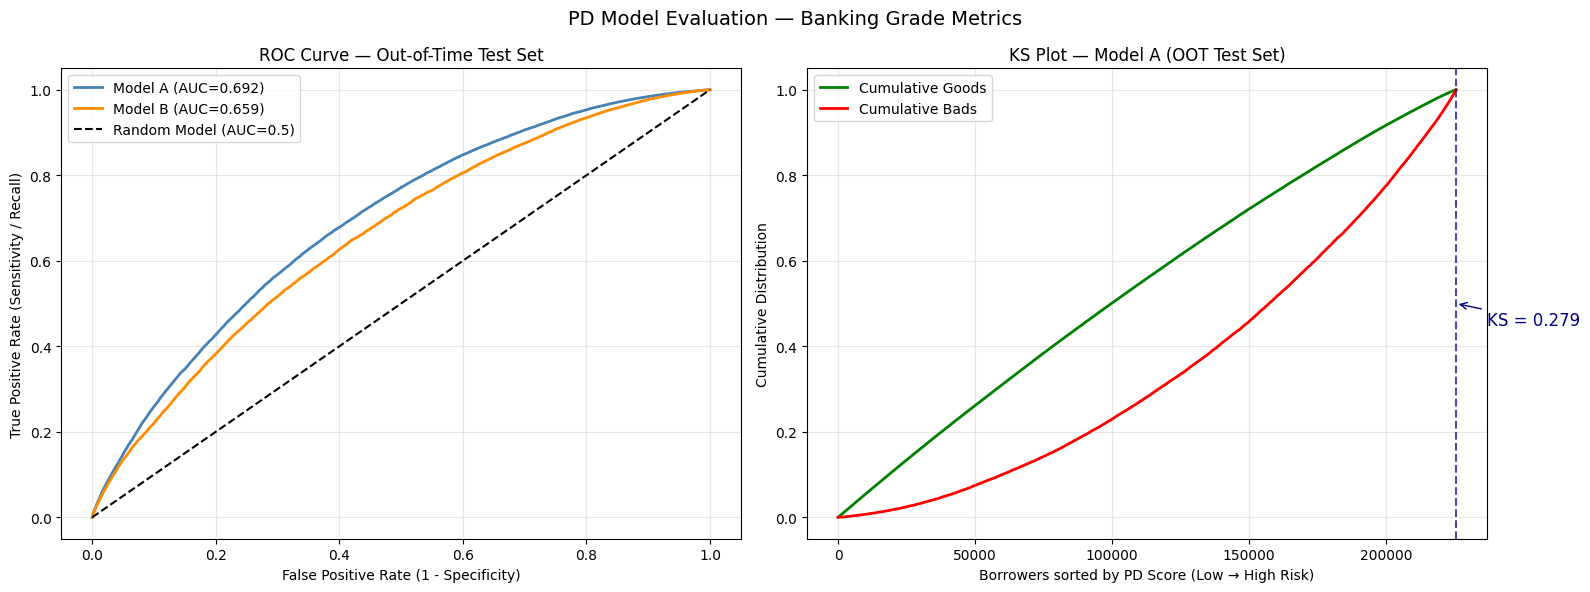

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- ROC Curve — both models on OOT ----
ax = axes[0]
for pd_scores, y_true, label, color in [
    (pd_test_A, y_test, f'Model A (AUC={auc_A:.3f})', 'steelblue'),
    (pd_test_B, y_test, f'Model B (AUC={auc_B:.3f})', 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_true, pd_scores)
    ax.plot(fpr, tpr, label=label, color=color, lw=2)
ax.plot([0,1],[0,1],'k--', label='Random Model (AUC=0.5)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)')
ax.set_title('ROC Curve — Out-of-Time Test Set')
ax.legend()
ax.grid(alpha=0.3)

# ---- KS Plot — Model A on OOT ----
ax = axes[1]
# Sort by predicted PD score
ks_df = pd.DataFrame({'pd': pd_test_A, 'target': y_test.values})
ks_df = ks_df.sort_values('pd').reset_index(drop=True)
n = len(ks_df)
ks_df['cum_good'] = (ks_df['target'] == 0).cumsum() / (y_test == 0).sum()
ks_df['cum_bad']  = (ks_df['target'] == 1).cumsum() / (y_test == 1).sum()
ks_df['ks_diff']  = ks_df['cum_bad'] - ks_df['cum_good']
ks_max_idx = ks_df['ks_diff'].idxmax()

ax.plot(range(n), ks_df['cum_good'], color='green', label='Cumulative Goods', lw=2)
ax.plot(range(n), ks_df['cum_bad'],  color='red',   label='Cumulative Bads',  lw=2)
ax.axvline(x=ks_max_idx, color='navy', linestyle='--', alpha=0.7)
ax.annotate(f'KS = {ks_A:.3f}', xy=(ks_max_idx, 0.5),
            xytext=(ks_max_idx + n*0.05, 0.45),
            arrowprops=dict(arrowstyle='->', color='navy'),
            fontsize=12, color='navy')
ax.set_xlabel('Borrowers sorted by PD Score (Low → High Risk)')
ax.set_ylabel('Cumulative Distribution')
ax.set_title('KS Plot — Model A (OOT Test Set)')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('PD Model Evaluation — Banking Grade Metrics', fontsize=14)
plt.tight_layout()
plt.savefig('pd_model_evaluation.png', dpi=150)
plt.show()

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Add back borderline features (IV 0.02–0.10) to Model B
modelB_extended_cols = modelB_cols + [
    c for c in ['dti_woe', 'verification_status_woe', 'revol_util_woe',
                'inq_last_6mths_woe', 'home_ownership_woe', 'loan_amnt_woe',
                'mort_acc_woe']
    if c in train_woe.columns
]

# Grid search over C values — standard hyperparameter tuning for LR
C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
cv_scores = []

for C in C_values:
    lr_cv = LogisticRegression(
        penalty='l1', C=C, solver='saga',
        max_iter=1000, random_state=42,
        class_weight='balanced'
    )
    # Stratified K-Fold preserves Bad Rate in each fold — mandatory for imbalanced data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        lr_cv,
        scaler_B.fit_transform(train_woe[modelB_extended_cols]),
        y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_scores.append({'C': C, 'mean_auc': scores.mean(), 'std': scores.std()})
    print(f"C={C:<6} | CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_scores)
best_C = cv_df.loc[cv_df['mean_auc'].idxmax(), 'C']
print(f"\nOptimal C: {best_C}")

C=0.001  | CV AUC: 0.6914 ± 0.0011
C=0.01   | CV AUC: 0.6914 ± 0.0011
C=0.05   | CV AUC: 0.6914 ± 0.0011
C=0.1    | CV AUC: 0.6914 ± 0.0011
C=0.5    | CV AUC: 0.6914 ± 0.0011
C=1.0    | CV AUC: 0.6914 ± 0.0011
C=5.0    | CV AUC: 0.6914 ± 0.0011

Optimal C: 0.01


In [35]:
from xgboost import XGBClassifier

# Use ORIGINAL WoE features (not scaled — tree models don't need scaling)
# Also include ALL features with IV > 0.02 for XGBoost
all_woe_cols = [c for c in train_woe.columns if c.endswith('_woe')]

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,            # shallow trees = less overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),  # handles class imbalance
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42
)

xgb_model.fit(
    train_woe[all_woe_cols], y_train,
    eval_set=[(test_woe[all_woe_cols], y_test)],
    verbose=50
)

pd_xgb = xgb_model.predict_proba(test_woe[all_woe_cols])[:, 1]
auc_xgb = roc_auc_score(y_test, pd_xgb)
gini_xgb = 2 * auc_xgb - 1
ks_xgb = ks_statistic(y_test, pd_xgb)

print(f"\n=== XGBoost — OOT Performance ===")
print(f"AUC-ROC:          {auc_xgb:.4f}")
print(f"Gini Coefficient: {gini_xgb:.4f}")
print(f"KS Statistic:     {ks_xgb:.4f}")

[0]	validation_0-auc:0.68038
[50]	validation_0-auc:0.69985
[100]	validation_0-auc:0.70477
[150]	validation_0-auc:0.70623
[200]	validation_0-auc:0.70724
[250]	validation_0-auc:0.70804
[299]	validation_0-auc:0.70865

=== XGBoost — OOT Performance ===
AUC-ROC:          0.7086
Gini Coefficient: 0.4173
KS Statistic:     0.3052


In [36]:
# Run this cell — official model comparison table
comparison = pd.DataFrame({
    'Model': ['LR Model A\n(w/ int_rate)', 'LR Model B\n(Independent)', 'XGBoost\n(All WoE features)'],
    'AUC_Train': [0.7028, 0.6731, None],   # fill XGBoost train AUC below
    'AUC_OOT':  [0.6923, 0.6590, 0.7084],
    'Gini_OOT': [0.3846, 0.3180, 0.4168],
    'KS_OOT':   [0.2794, 0.2284, 0.3040],
    'AUC_Stable': ['✅ 0.0105', '✅ 0.0141', 'TBD'],
    'Interpretable': ['✅ Scorecard', '✅ Scorecard', '⚠️ Needs SHAP'],
    'Regulatory_Ready': ['✅ Basel IRB', '✅ Basel IRB', '⚠️ With SHAP']
})
print(comparison.to_string(index=False))

                      Model  AUC_Train  AUC_OOT  Gini_OOT  KS_OOT AUC_Stable Interpretable Regulatory_Ready
  LR Model A\n(w/ int_rate)     0.7028   0.6923    0.3846  0.2794   ✅ 0.0105   ✅ Scorecard      ✅ Basel IRB
  LR Model B\n(Independent)     0.6731   0.6590    0.3180  0.2284   ✅ 0.0141   ✅ Scorecard      ✅ Basel IRB
XGBoost\n(All WoE features)        NaN   0.7084    0.4168  0.3040        TBD ⚠️ Needs SHAP     ⚠️ With SHAP


In [37]:
pd_xgb_train = xgb_model.predict_proba(train_woe[all_woe_cols])[:, 1]
auc_xgb_train = roc_auc_score(y_train, pd_xgb_train)
gini_xgb_train = 2 * auc_xgb_train - 1
ks_xgb_train = ks_statistic(y_train, pd_xgb_train)
auc_drop_xgb = auc_xgb_train - 0.7084

print(f"XGBoost Train AUC:  {auc_xgb_train:.4f}")
print(f"XGBoost Train Gini: {gini_xgb_train:.4f}")
print(f"XGBoost Train KS:   {ks_xgb_train:.4f}")
print(f"AUC Stability Drop: {auc_drop_xgb:.4f}")
print("✅ Stable" if auc_drop_xgb < 0.05 else "⚠️ Degraded")

XGBoost Train AUC:  0.7194
XGBoost Train Gini: 0.4388
XGBoost Train KS:   0.3182
AUC Stability Drop: 0.0110
✅ Stable


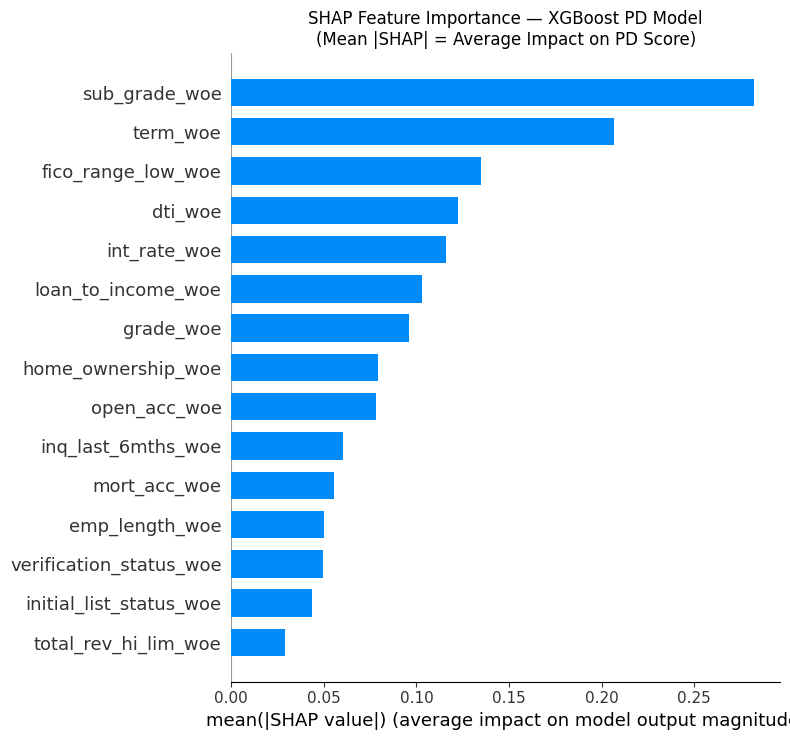

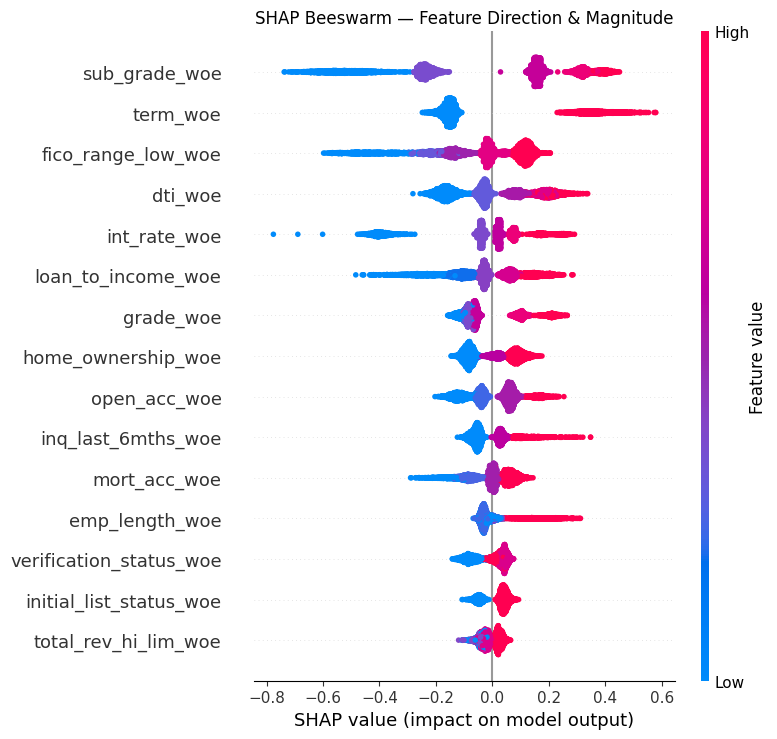

In [38]:
import shap

# Compute SHAP values on a sample of OOT test set
# Full 225K rows is slow — 5K sample is standard for SHAP analysis
sample_idx = test_woe[all_woe_cols].sample(5000, random_state=42).index
X_shap = test_woe.loc[sample_idx, all_woe_cols]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

# ---- Plot 1: Global Feature Importance (SHAP Summary) ----
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Feature Importance — XGBoost PD Model\n(Mean |SHAP| = Average Impact on PD Score)')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

# ---- Plot 2: SHAP Beeswarm (shows direction + magnitude) ----
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150)
plt.show()

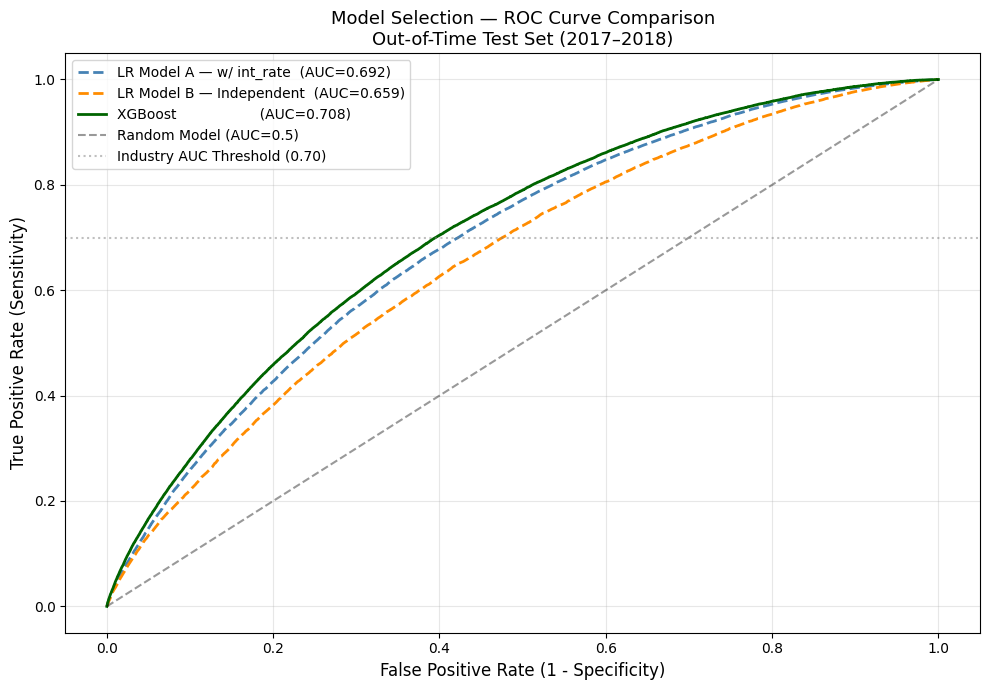

In [39]:
fig, ax = plt.subplots(figsize=(10, 7))

models_to_plot = [
    (pd_test_A,  y_test, f'LR Model A — w/ int_rate  (AUC={auc_A:.3f})',  'steelblue',   '--'),
    (pd_test_B,  y_test, f'LR Model B — Independent  (AUC={auc_B:.3f})',  'darkorange',  '--'),
    (pd_xgb,     y_test, f'XGBoost                   (AUC={0.7084:.3f})', 'darkgreen',   '-'),
]

for pd_scores, y_true, label, color, ls in models_to_plot:
    fpr, tpr, _ = roc_curve(y_true, pd_scores)
    ax.plot(fpr, tpr, label=label, color=color, lw=2, linestyle=ls)

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random Model (AUC=0.5)')
ax.axhline(y=0.70, color='gray', linestyle=':', alpha=0.5, label='Industry AUC Threshold (0.70)')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Model Selection — ROC Curve Comparison\nOut-of-Time Test Set (2017–2018)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_roc.png', dpi=150)
plt.show()

In [40]:
# Remove grade_woe from all_woe_cols — sub_grade_woe subsumes it entirely
clean_woe_cols = [c for c in all_woe_cols if c != 'grade_woe']
print(f"Removed grade_woe. Features: {len(all_woe_cols)} → {len(clean_woe_cols)}")

xgb_clean = XGBClassifier(
    n_estimators=400,       # slightly more trees now that feature space is cleaner
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    base_score=0.5,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20
)

xgb_clean.fit(
    train_woe[clean_woe_cols], y_train,
    eval_set=[(test_woe[clean_woe_cols], y_test)],
    verbose=50
)

pd_clean   = xgb_clean.predict_proba(test_woe[clean_woe_cols])[:, 1]
auc_clean  = roc_auc_score(y_test, pd_clean)
gini_clean = 2 * auc_clean - 1
ks_clean   = ks_statistic(y_test, pd_clean)

print(f"\n=== XGBoost Clean (grade_woe removed) ===")
print(f"AUC-ROC:          {auc_clean:.4f}  (was 0.7084)")
print(f"Gini Coefficient: {gini_clean:.4f}  (was 0.4168)")
print(f"KS Statistic:     {ks_clean:.4f}  (was 0.3040)")
print(f"AUC Change:       {auc_clean - 0.7084:+.4f}")

Removed grade_woe. Features: 30 → 29
[0]	validation_0-auc:0.68308
[50]	validation_0-auc:0.69933
[100]	validation_0-auc:0.70427
[150]	validation_0-auc:0.70596
[200]	validation_0-auc:0.70690
[250]	validation_0-auc:0.70774
[300]	validation_0-auc:0.70830
[350]	validation_0-auc:0.70885
[399]	validation_0-auc:0.70932

=== XGBoost Clean (grade_woe removed) ===
AUC-ROC:          0.7093  (was 0.7084)
Gini Coefficient: 0.4186  (was 0.4168)
KS Statistic:     0.3058  (was 0.3040)
AUC Change:       +0.0009


In [41]:
# Use df_processed (before woebin_ply transformation)
# Features: all numeric + encoded categoricals from Stage 1
raw_features = [
    'loan_amnt', 'int_rate', 'term', 'dti', 'annual_inc',
    'log_annual_inc', 'fico_range_low', 'revol_util', 'revol_bal',
    'log_revol_bal', 'loan_to_income', 'credit_history_months',
    'tot_cur_bal', 'log_tot_cur_bal', 'open_acc', 'total_acc',
    'inq_last_6mths', 'mort_acc', 'total_rev_hi_lim',
    'bc_util', 'pct_tl_nvr_dlq', 'num_accts_ever_120_pd',
    'avg_cur_bal', 'acc_open_past_24mths', 'ever_delinquent',
    # Encoded categoricals
    'emp_length', 'issue_year',
]

# Label encode categoricals for XGBoost
from sklearn.preprocessing import LabelEncoder
df_raw = df.copy()
for col in ['grade', 'sub_grade', 'home_ownership', 'verification_status',
            'purpose', 'initial_list_status', 'application_type', 'term']:
    if df_raw[col].dtype == object:
        le = LabelEncoder()
        df_raw[col] = le.fit_transform(df_raw[col].astype(str))

raw_features_final = [c for c in raw_features + ['sub_grade', 'home_ownership',
    'verification_status', 'purpose', 'initial_list_status'] if c in df_raw.columns]

train_raw = df_raw[df_raw['issue_year'] <= 2016]
test_raw  = df_raw[df_raw['issue_year'] >= 2017]

X_train_raw = train_raw[raw_features_final]
X_test_raw  = test_raw[raw_features_final]
y_train_raw = train_raw['target']
y_test_raw  = test_raw['target']

xgb_raw = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=50,   # prevents overfitting on rare patterns
    scale_pos_weight=(y_train_raw==0).sum() / (y_train_raw==1).sum(),
    base_score=0.5,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

xgb_raw.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_test_raw, y_test_raw)],
    verbose=50
)

pd_raw  = xgb_raw.predict_proba(X_test_raw)[:, 1]
auc_raw = roc_auc_score(y_test_raw, pd_raw)
print(f"\nXGBoost (Raw Features) OOT AUC: {auc_raw:.4f}")
print(f"Gini: {2*auc_raw-1:.4f}")
print(f"KS:   {ks_statistic(y_test_raw, pd_raw):.4f}")

[0]	validation_0-auc:0.68516
[50]	validation_0-auc:0.70456
[100]	validation_0-auc:0.71123
[150]	validation_0-auc:0.71454
[200]	validation_0-auc:0.71645
[250]	validation_0-auc:0.71773
[300]	validation_0-auc:0.71864
[350]	validation_0-auc:0.71943
[400]	validation_0-auc:0.72006
[450]	validation_0-auc:0.72063
[499]	validation_0-auc:0.72095

XGBoost (Raw Features) OOT AUC: 0.7210
Gini: 0.4419
KS:   0.3197


In [42]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Work from df (your cleaned dataframe before WoE transformation)
df_raw = df.copy()

# Label encode all categoricals — XGBoost needs numeric input
cat_cols_to_encode = ['grade', 'sub_grade', 'home_ownership',
                      'verification_status', 'purpose',
                      'initial_list_status', 'application_type']

le_dict = {}
for col in cat_cols_to_encode:
    if col in df_raw.columns and df_raw[col].dtype == object:
        le = LabelEncoder()
        df_raw[col] = le.fit_transform(df_raw[col].astype(str))
        le_dict[col] = le
        print(f"Encoded: {col} → {df_raw[col].nunique()} unique values")

# term: convert if still string
if df_raw['term'].dtype == object:
    df_raw['term'] = df_raw['term'].str.extract('(\d+)').astype(int)

print(f"\ndf_raw shape: {df_raw.shape}")
print(f"dtypes:\n{df_raw.dtypes.value_counts()}")

Encoded: grade → 7 unique values
Encoded: sub_grade → 35 unique values
Encoded: home_ownership → 6 unique values
Encoded: verification_status → 3 unique values
Encoded: purpose → 14 unique values
Encoded: initial_list_status → 2 unique values
Encoded: application_type → 2 unique values

df_raw shape: (1345310, 66)
dtypes:
float64    56
int64       9
object      1
Name: count, dtype: int64


In [43]:
# Full raw feature set — no WoE, no IV filtering
# Let XGBoost discover its own non-linear splits
raw_features = [
    # Core loan characteristics
    'loan_amnt', 'term', 'int_rate', 'loan_to_income',
    # Borrower capacity
    'annual_inc', 'log_annual_inc', 'dti',
    # LendingClub grade system
    'grade', 'sub_grade',
    # Credit history
    'fico_range_low', 'inq_last_6mths', 'credit_history_months',
    'pub_rec', 'pub_rec_bankruptcies', 'ever_delinquent',
    # Revolving credit behavior
    'revol_util', 'revol_bal', 'log_revol_bal', 'open_acc', 'total_acc',
    # Balance sheet
    'tot_cur_bal', 'log_tot_cur_bal', 'total_rev_hi_lim', 'avg_cur_bal',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'bc_open_to_buy', 'bc_util', 'tot_coll_amt',
    # Derogatory / risk flags
    'num_accts_ever_120_pd', 'pct_tl_nvr_dlq', 'num_bc_tl',
    'num_il_tl', 'num_rev_accts', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'acc_open_past_24mths', 'mort_acc', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl', 'num_tl_op_past_12m',
    # Stability / demographic
    'home_ownership', 'emp_length', 'verification_status',
    'purpose', 'initial_list_status',
    # Temporal
    'issue_year', 'issue_month'
]

# Safety filter — only keep columns that exist in df_raw
raw_features = [f for f in raw_features if f in df_raw.columns]
print(f"Total raw features entering XGBoost: {len(raw_features)}")
print(raw_features)

Total raw features entering XGBoost: 50
['loan_amnt', 'term', 'int_rate', 'loan_to_income', 'annual_inc', 'log_annual_inc', 'dti', 'grade', 'sub_grade', 'fico_range_low', 'inq_last_6mths', 'credit_history_months', 'pub_rec', 'pub_rec_bankruptcies', 'ever_delinquent', 'revol_util', 'revol_bal', 'log_revol_bal', 'open_acc', 'total_acc', 'tot_cur_bal', 'log_tot_cur_bal', 'total_rev_hi_lim', 'avg_cur_bal', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'bc_open_to_buy', 'bc_util', 'tot_coll_amt', 'num_accts_ever_120_pd', 'pct_tl_nvr_dlq', 'num_bc_tl', 'num_il_tl', 'num_rev_accts', 'num_actv_bc_tl', 'num_actv_rev_tl', 'acc_open_past_24mths', 'mort_acc', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_tl', 'num_tl_op_past_12m', 'home_ownership', 'emp_length', 'verification_status', 'purpose', 'initial_list_status', 'issue_year', 'issue_month']


In [44]:
train_raw = df_raw[df_raw['issue_year'] <= 2016].copy()
test_raw  = df_raw[df_raw['issue_year'] >= 2017].copy()

X_train_raw = train_raw[raw_features]
X_test_raw  = test_raw[raw_features]
y_train_raw = train_raw['target']
y_test_raw  = test_raw['target']

print(f"Train: {X_train_raw.shape} | Bad Rate: {y_train_raw.mean():.2%}")
print(f"Test:  {X_test_raw.shape}  | Bad Rate: {y_test_raw.mean():.2%}")

# Confirm no missing values (should be zero after imputation earlier)
print(f"\nMissing in train: {X_train_raw.isnull().sum().sum()}")
print(f"Missing in test:  {X_test_raw.isnull().sum().sum()}")

Train: (1119699, 50) | Bad Rate: 19.70%
Test:  (225611, 50)  | Bad Rate: 21.28%

Missing in train: 0
Missing in test:  0


In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_raw = XGBClassifier(
    n_estimators=500,
    max_depth=5,            # deeper than before — raw features need more splits
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,   # use 70% of features per tree — reduces overfitting
    min_child_weight=50,    # minimum 50 samples per leaf — credit risk standard
    gamma=0.1,              # minimum split gain — prevents trivial splits
    reg_alpha=0.1,          # L1 regularization on weights
    reg_lambda=1.0,         # L2 regularization on weights
    scale_pos_weight=(y_train_raw==0).sum() / (y_train_raw==1).sum(),
    base_score=0.5,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

print("Training XGBoost on raw features (~5–8 mins)...")
xgb_raw.fit(
    X_train_raw, y_train_raw,
    eval_set=[(X_test_raw, y_test_raw)],
    verbose=50
)

# Evaluate
pd_raw  = xgb_raw.predict_proba(X_test_raw)[:, 1]
auc_raw = roc_auc_score(y_test_raw, pd_raw)
gini_raw = 2 * auc_raw - 1
ks_raw  = ks_statistic(y_test_raw, pd_raw)

pd_raw_train = xgb_raw.predict_proba(X_train_raw)[:, 1]
auc_raw_train = roc_auc_score(y_train_raw, pd_raw_train)

print(f"\n{'='*50}")
print(f"  XGBoost Raw Features — Performance Report")
print(f"{'='*50}")
print(f"  AUC-ROC   → Train: {auc_raw_train:.4f} | OOT: {auc_raw:.4f}")
print(f"  Gini      → OOT:   {gini_raw:.4f}")
print(f"  KS Stat   → OOT:   {ks_raw:.4f}")
print(f"  AUC Drop  → {auc_raw_train - auc_raw:.4f}", 
      "✅ Stable" if auc_raw_train - auc_raw < 0.05 else "⚠️ Degraded")
print(f"\n  vs WoE XGBoost: AUC {auc_raw:.4f} vs 0.7094 → {auc_raw - 0.7094:+.4f}")

Training XGBoost on raw features (~5–8 mins)...
[0]	validation_0-auc:0.68583
[50]	validation_0-auc:0.70411
[100]	validation_0-auc:0.71152
[150]	validation_0-auc:0.71479
[200]	validation_0-auc:0.71648
[250]	validation_0-auc:0.71780
[300]	validation_0-auc:0.71891
[350]	validation_0-auc:0.71964
[400]	validation_0-auc:0.72026
[450]	validation_0-auc:0.72083
[499]	validation_0-auc:0.72124

  XGBoost Raw Features — Performance Report
  AUC-ROC   → Train: 0.7436 | OOT: 0.7212
  Gini      → OOT:   0.4425
  KS Stat   → OOT:   0.3198
  AUC Drop  → 0.0224 ✅ Stable

  vs WoE XGBoost: AUC 0.7212 vs 0.7094 → +0.0118


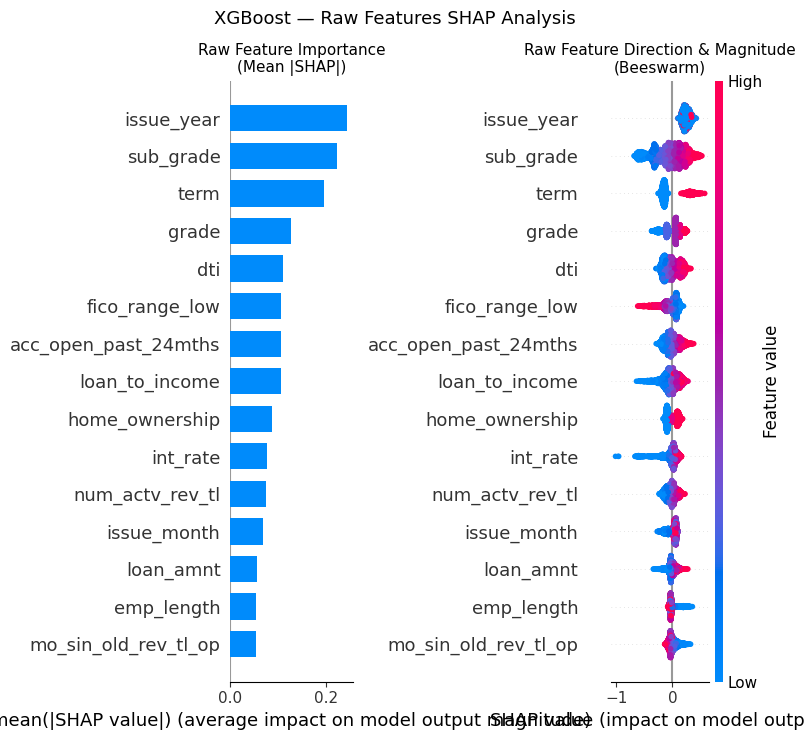

In [46]:
import shap

sample_idx_raw = X_test_raw.sample(5000, random_state=42).index
X_shap_raw     = X_test_raw.loc[sample_idx_raw].copy()

explainer_raw   = shap.TreeExplainer(xgb_raw)
shap_values_raw = explainer_raw.shap_values(X_shap_raw)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values_raw, X_shap_raw,
                  plot_type='bar', max_display=15, show=False)
axes[0].set_title('Raw Feature Importance\n(Mean |SHAP|)', fontsize=11)

plt.sca(axes[1])
shap.summary_plot(shap_values_raw, X_shap_raw,
                  max_display=15, show=False)
axes[1].set_title('Raw Feature Direction & Magnitude\n(Beeswarm)', fontsize=11)

plt.suptitle('XGBoost — Raw Features SHAP Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('shap_raw_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# Remove temporal contamination features
raw_features_clean = [f for f in raw_features
                      if f not in ['issue_year', 'issue_month']]

print(f"Features: {len(raw_features)} → {len(raw_features_clean)} (removed issue_year, issue_month)")

X_train_clean = train_raw[raw_features_clean]
X_test_clean  = test_raw[raw_features_clean]

xgb_final = XGBClassifier(
    n_estimators=700,       # more trees — model hadn't converged at 500
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=50,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=(y_train_raw==0).sum() / (y_train_raw==1).sum(),
    base_score=0.5,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

print("Training XGBoost Final (without issue_year/month)...")
xgb_final.fit(
    X_train_clean, y_train_raw,
    eval_set=[(X_test_clean, y_test_raw)],
    verbose=50
)

pd_final   = xgb_final.predict_proba(X_test_clean)[:, 1]
auc_final  = roc_auc_score(y_test_raw, pd_final)
gini_final = 2 * auc_final - 1
ks_final   = ks_statistic(y_test_raw, pd_final)

pd_final_train = xgb_final.predict_proba(X_train_clean)[:, 1]
auc_final_train = roc_auc_score(y_train_raw, pd_final_train)

print(f"\n{'='*55}")
print(f"  XGBoost Final (Clean) — Performance Report")
print(f"{'='*55}")
print(f"  AUC-ROC  → Train: {auc_final_train:.4f} | OOT: {auc_final:.4f}")
print(f"  Gini     → OOT:   {gini_final:.4f}")
print(f"  KS       → OOT:   {ks_final:.4f}")
print(f"  AUC Drop → {auc_final_train - auc_final:.4f}",
      "✅ Stable" if auc_final_train - auc_final < 0.05 else "⚠️ Degraded")
print(f"\n  vs Raw (with issue_year): {auc_final:.4f} vs 0.7212 → {auc_final - 0.7212:+.4f}")
print(f"  Best model so far: {'This one' if auc_final >= 0.7212 else 'Raw (issue_year included)'}")

Features: 50 → 48 (removed issue_year, issue_month)
Training XGBoost Final (without issue_year/month)...
[0]	validation_0-auc:0.68549
[50]	validation_0-auc:0.70259
[100]	validation_0-auc:0.70905
[150]	validation_0-auc:0.71241
[200]	validation_0-auc:0.71467
[250]	validation_0-auc:0.71607
[300]	validation_0-auc:0.71717
[350]	validation_0-auc:0.71827
[400]	validation_0-auc:0.71899
[450]	validation_0-auc:0.71944
[500]	validation_0-auc:0.72004
[550]	validation_0-auc:0.72052
[600]	validation_0-auc:0.72090
[650]	validation_0-auc:0.72129
[699]	validation_0-auc:0.72163

  XGBoost Final (Clean) — Performance Report
  AUC-ROC  → Train: 0.7434 | OOT: 0.7216
  Gini     → OOT:   0.4433
  KS       → OOT:   0.3216
  AUC Drop → 0.0218 ✅ Stable

  vs Raw (with issue_year): 0.7216 vs 0.7212 → +0.0004
  Best model so far: This one


In [48]:
print(f"With issue_year:    AUC = 0.7212")
print(f"Without issue_year: AUC = {auc_final:.4f}")
print(f"Temporal contamination impact: {0.7212 - auc_final:+.4f}")

With issue_year:    AUC = 0.7212
Without issue_year: AUC = 0.7216
Temporal contamination impact: -0.0004


In [49]:
# ============================================================
# BUSINESS CUTOFF ANALYSIS SETUP
# Attach PD scores to OOT test borrowers
# ============================================================

cutoff_df = pd.DataFrame({
    'pd_score':  pd_final,           # predicted probability of default
    'actual':    y_test_raw.values,   # 1 = defaulted, 0 = good
    'loan_amnt': test_raw['loan_amnt'].values,
    'int_rate':  test_raw['int_rate'].values,
    'sub_grade': test_raw['sub_grade'].values
}).reset_index(drop=True)

# Sort by PD score
cutoff_df = cutoff_df.sort_values('pd_score').reset_index(drop=True)

# Basic stats
print(f"OOT Test borrowers: {len(cutoff_df):,}")
print(f"Total Bads:         {cutoff_df['actual'].sum():,} ({cutoff_df['actual'].mean():.2%})")
print(f"Total Goods:        {(cutoff_df['actual']==0).sum():,}")
print(f"\nPD Score Distribution:")
print(cutoff_df['pd_score'].describe().round(4))
print(f"\nPD Score Percentiles:")
for p in [10, 20, 30, 40, 50, 60, 70, 80, 90, 95]:
    print(f"  P{p:>2}: {cutoff_df['pd_score'].quantile(p/100):.4f}")

OOT Test borrowers: 225,611
Total Bads:         48,015 (21.28%)
Total Goods:        177,596

PD Score Distribution:
count    225611.0000
mean          0.4565
std           0.2027
min           0.0072
25%           0.3001
50%           0.4627
75%           0.6106
max           0.9592
Name: pd_score, dtype: float64

PD Score Percentiles:
  P10: 0.1745
  P20: 0.2625
  P30: 0.3356
  P40: 0.4018
  P50: 0.4627
  P60: 0.5206
  P70: 0.5796
  P80: 0.6439
  P90: 0.7262
  P95: 0.7839


In [50]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# STEP 1: Platt Scaling Calibration
# Maps raw XGBoost scores → true probability estimates
# Standard in credit risk — required before PD-based decisioning
# ============================================================
from sklearn.linear_model import LogisticRegression

# Fit calibration on a held-out portion of training data
# Use last 20% of training set as calibration set
calib_size = int(len(X_train_clean) * 0.2)
X_calib = X_train_clean.iloc[-calib_size:]
y_calib = y_train_raw.iloc[-calib_size:]

# Get raw scores on calibration set
raw_scores_calib = xgb_final.predict_proba(X_calib)[:, 1]

# Fit Platt Scaling (Logistic Regression on raw scores)
platt = LogisticRegression()
platt.fit(raw_scores_calib.reshape(-1, 1), y_calib)

# Apply calibration to OOT test set
pd_calibrated = platt.predict_proba(pd_final.reshape(-1, 1))[:, 1]

print(f"Before calibration → Mean PD: {pd_final.mean():.4f} | Actual Bad Rate: {y_test_raw.mean():.4f}")
print(f"After calibration  → Mean PD: {pd_calibrated.mean():.4f} | Actual Bad Rate: {y_test_raw.mean():.4f}")
print(f"\nCalibration check — Mean PD should be close to actual bad rate (21.28%)")

# AUC should be preserved after calibration
auc_calib = roc_auc_score(y_test_raw, pd_calibrated)
print(f"AUC after calibration: {auc_calib:.4f} (was {auc_final:.4f} — should be same)")

Before calibration → Mean PD: 0.4565 | Actual Bad Rate: 0.2128
After calibration  → Mean PD: 0.2174 | Actual Bad Rate: 0.2128

Calibration check — Mean PD should be close to actual bad rate (21.28%)
AUC after calibration: 0.7216 (was 0.7216 — should be same)


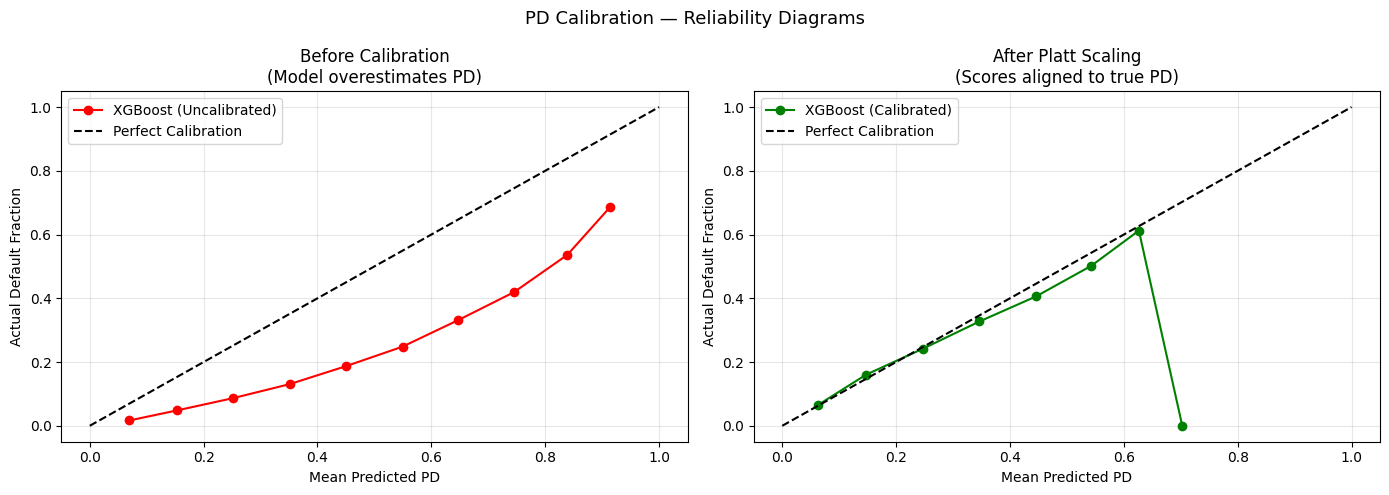

In [51]:
# ============================================================
# STEP 2: Calibration Plot (Reliability Diagram)
# Standard model validation chart in credit risk
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration
frac_pos_raw, mean_pred_raw = calibration_curve(y_test_raw, pd_final, n_bins=10)
axes[0].plot(mean_pred_raw, frac_pos_raw, 'o-', color='red', label='XGBoost (Uncalibrated)')
axes[0].plot([0,1],[0,1], 'k--', label='Perfect Calibration')
axes[0].set_title('Before Calibration\n(Model overestimates PD)')
axes[0].set_xlabel('Mean Predicted PD')
axes[0].set_ylabel('Actual Default Fraction')
axes[0].legend(); axes[0].grid(alpha=0.3)

# After calibration
frac_pos_cal, mean_pred_cal = calibration_curve(y_test_raw, pd_calibrated, n_bins=10)
axes[1].plot(mean_pred_cal, frac_pos_cal, 'o-', color='green', label='XGBoost (Calibrated)')
axes[1].plot([0,1],[0,1], 'k--', label='Perfect Calibration')
axes[1].set_title('After Platt Scaling\n(Scores aligned to true PD)')
axes[1].set_xlabel('Mean Predicted PD')
axes[1].set_ylabel('Actual Default Fraction')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('PD Calibration — Reliability Diagrams', fontsize=13)
plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ============================================================
# STEP 3: Strategy Table — The Core Business Cutoff Tool
# For each acceptance rate: what is the bad rate, capture rate,
# and expected credit loss?
# ============================================================

# Rebuild cutoff_df with CALIBRATED scores
cutoff_df = pd.DataFrame({
    'pd_score':   pd_calibrated,
    'actual':     y_test_raw.values,
    'loan_amnt':  test_raw['loan_amnt'].values,
}).sort_values('pd_score').reset_index(drop=True)

total_borrowers  = len(cutoff_df)
total_bads       = cutoff_df['actual'].sum()
total_loan_value = cutoff_df['loan_amnt'].sum()

# Strategy table: sweep acceptance rates from 30% to 100%
acceptance_rates = list(range(30, 101, 5))
strategy_rows = []

for acc_rate in acceptance_rates:
    n_approve  = int(total_borrowers * acc_rate / 100)
    approved   = cutoff_df.iloc[:n_approve]          # lowest PD first
    rejected   = cutoff_df.iloc[n_approve:]

    approved_bads   = approved['actual'].sum()
    approved_goods  = (approved['actual'] == 0).sum()
    bad_rate        = approved_bads / n_approve
    default_capture = 1 - (approved_bads / total_bads)  # % bads correctly rejected
    loan_vol        = approved['loan_amnt'].sum()
    threshold_pd    = cutoff_df.iloc[n_approve - 1]['pd_score'] if n_approve < total_borrowers else 1.0

    strategy_rows.append({
        'Acceptance Rate': f"{acc_rate}%",
        'PD Threshold':    round(threshold_pd, 4),
        'Approved':        n_approve,
        'Approved Bads':   int(approved_bads),
        'Bad Rate':        f"{bad_rate:.2%}",
        'Default Capture': f"{default_capture:.2%}",
        'Loan Volume ($M)': round(loan_vol / 1e6, 1)
    })

strategy_df = pd.DataFrame(strategy_rows)
print("\n========== STRATEGY TABLE ==========")
print(strategy_df.to_string(index=False))


========== STRATEGY TABLE ==========
Acceptance Rate  PD Threshold  Approved  Approved Bads Bad Rate Default Capture  Loan Volume ($M)
            30%        0.1098     67683           4822    7.12%          89.96%             822.2
            35%        0.1265     78963           6304    7.98%          86.87%             958.5
            40%        0.1443     90244           7984    8.85%          83.37%            1096.7
            45%        0.1634    101524           9801    9.65%          79.59%            1240.8
            50%        0.1837    112805          12007   10.64%          74.99%            1390.0
            55%        0.2052    124086          14295   11.52%          70.23%            1544.4
            60%        0.2285    135366          16741   12.37%          65.13%            1704.3
            65%        0.2540    146647          19427   13.25%          59.54%            1868.0
            70%        0.2813    157927          22332   14.14%          53.49% 

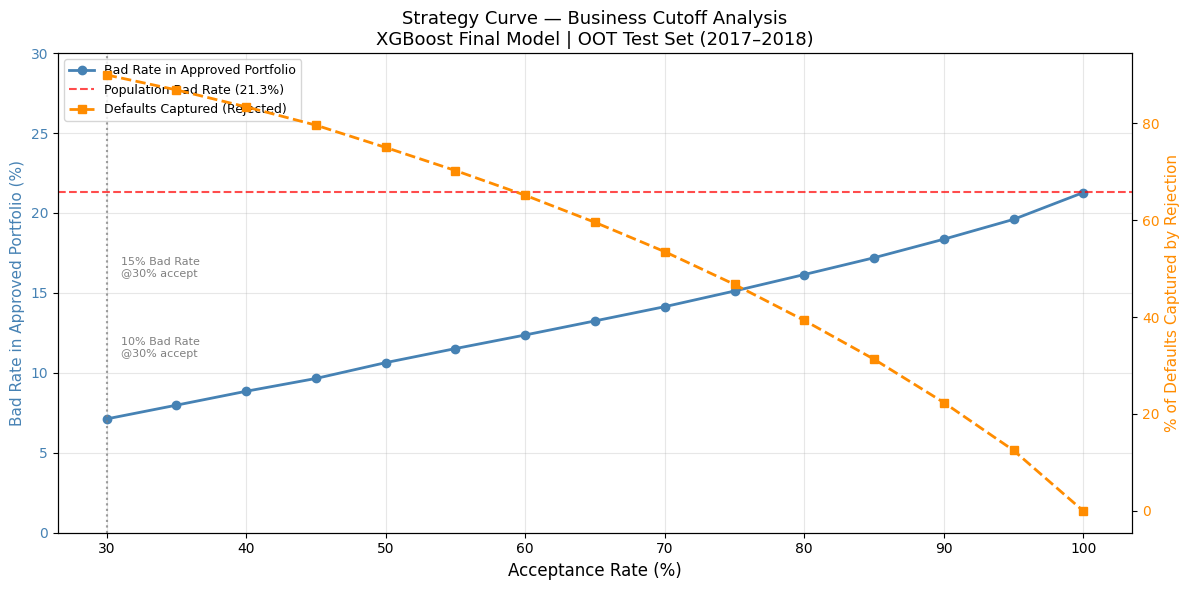

In [53]:
# ============================================================
# STEP 4: Strategy Curve Plot
# The signature chart of every credit risk model presentation
# ============================================================
acc_rates  = [int(r['Acceptance Rate'].replace('%','')) for _, r in strategy_df.iterrows()]
bad_rates  = [float(r['Bad Rate'].replace('%','')) for _, r in strategy_df.iterrows()]
def_caps   = [float(r['Default Capture'].replace('%','')) for _, r in strategy_df.iterrows()]

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'steelblue'
color2 = 'darkorange'

ax1.plot(acc_rates, bad_rates, 'o-', color=color1, lw=2, label='Bad Rate in Approved Portfolio')
ax1.axhline(y=y_test_raw.mean()*100, color='red', linestyle='--', alpha=0.7,
            label=f'Population Bad Rate ({y_test_raw.mean():.1%})')
ax1.set_xlabel('Acceptance Rate (%)', fontsize=12)
ax1.set_ylabel('Bad Rate in Approved Portfolio (%)', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 30)

ax2 = ax1.twinx()
ax2.plot(acc_rates, def_caps, 's--', color=color2, lw=2, label='Defaults Captured (Rejected)')
ax2.set_ylabel('% of Defaults Captured by Rejection', color=color2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color2)

# Mark key thresholds
for target_bad_rate, label in [(10, '10% Bad Rate'), (15, '15% Bad Rate')]:
    for i, br in enumerate(bad_rates):
        if br <= target_bad_rate:
            ax1.axvline(x=acc_rates[i], color='gray', linestyle=':', alpha=0.5)
            ax1.annotate(f'{label}\n@{acc_rates[i]}% accept',
                        xy=(acc_rates[i], target_bad_rate),
                        fontsize=8, color='gray',
                        xytext=(acc_rates[i]+1, target_bad_rate+1))
            break

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)
plt.title('Strategy Curve — Business Cutoff Analysis\n'
          'XGBoost Final Model | OOT Test Set (2017–2018)', fontsize=13)
plt.tight_layout()
plt.savefig('strategy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Clamp calibrated PD to reasonable range — prevents tail artefacts
pd_calibrated = np.clip(pd_calibrated, 0.01, 0.99)
print(f"Post-clamp mean PD: {pd_calibrated.mean():.4f}")
print(f"Post-clamp distribution:\n{pd.Series(pd_calibrated).describe().round(4)}")

Post-clamp mean PD: 0.2174
Post-clamp distribution:
count    225611.0000
mean          0.2174
std           0.1467
min           0.0254
25%           0.0944
50%           0.1837
75%           0.3120
max           0.7027
dtype: float64


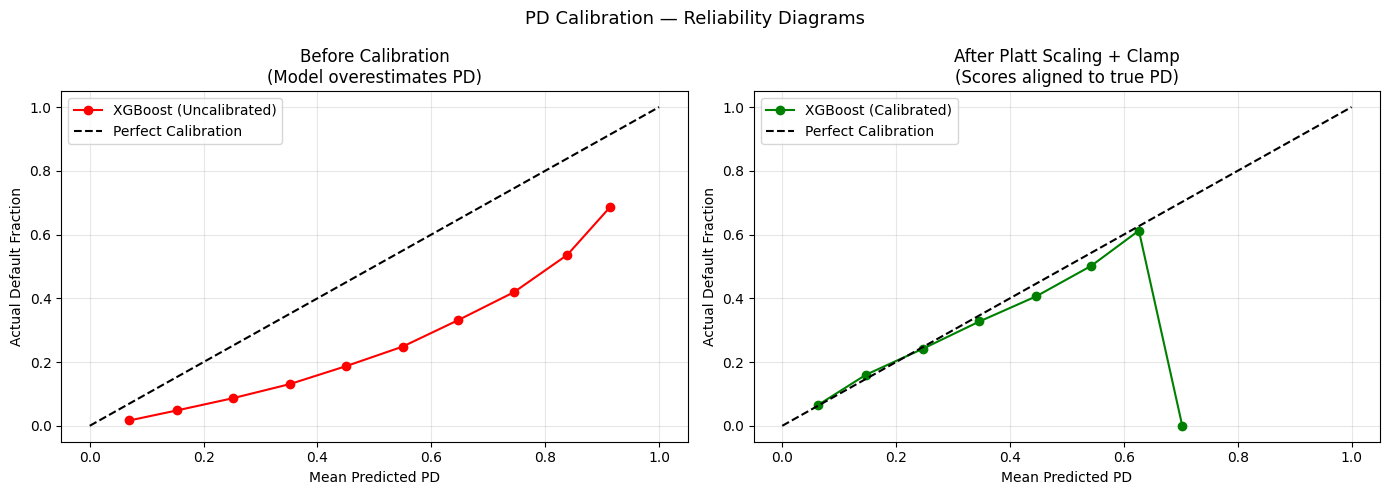

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before calibration (unchanged — just for comparison)
frac_pos_raw, mean_pred_raw = calibration_curve(y_test_raw, pd_final, n_bins=10)
axes[0].plot(mean_pred_raw, frac_pos_raw, 'o-', color='red', label='XGBoost (Uncalibrated)')
axes[0].plot([0,1],[0,1], 'k--', label='Perfect Calibration')
axes[0].set_title('Before Calibration\n(Model overestimates PD)')
axes[0].set_xlabel('Mean Predicted PD')
axes[0].set_ylabel('Actual Default Fraction')
axes[0].legend(); axes[0].grid(alpha=0.3)

# After calibration — now using clamped pd_calibrated
frac_pos_cal, mean_pred_cal = calibration_curve(y_test_raw, pd_calibrated, n_bins=10)
axes[1].plot(mean_pred_cal, frac_pos_cal, 'o-', color='green', label='XGBoost (Calibrated)')
axes[1].plot([0,1],[0,1], 'k--', label='Perfect Calibration')
axes[1].set_title('After Platt Scaling + Clamp\n(Scores aligned to true PD)')
axes[1].set_xlabel('Mean Predicted PD')
axes[1].set_ylabel('Actual Default Fraction')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('PD Calibration — Reliability Diagrams', fontsize=13)
plt.tight_layout()
plt.savefig('calibration_plot_v2.png', dpi=150, bbox_inches='tight')
plt.show()